# BUSA8031 — Business Analytics Project
## NSW Data Centre Electricity Analysis
### Tasks 1–4 | Macquarie Business School

**Data sources:**
- `NSW Price and Demand 20210701_20240630.xlsx` — AEMO 5-minute settlement data, FY2022–FY2024
- `Solar Farm Dispatch Data.xlsx` — 102 MW NSW solar farm 5-minute dispatch data

---
**Notebook structure:**
1. Setup & Data Loading
2. Task 3 — Data Centre Demand Profile *(built first; used by Tasks 2 & 4)*
3. Task 1 — NSW Data Centre Demand Growth Scenarios
4. Task 2 — Price-Impact Modelling
5. Task 4 — Electricity Cost & Risk Management Strategy


In [1]:
from google.colab import files
uploaded = files.upload()

Saving NSW Price and Demand 20210701_20240630.xlsx to NSW Price and Demand 20210701_20240630.xlsx
Saving Solar Farm Dispatch Data.xlsx to Solar Farm Dispatch Data.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import norm

# Consistent plot style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


In [3]:
# ── Load raw data ────────────────────────────────────────────────────
df = pd.read_excel('NSW Price and Demand 20210701_20240630.xlsx')
df_solar = pd.read_excel('Solar Farm Dispatch Data.xlsx')

df.rename(columns={'SETTLEMENTDATE': 'datetime',
                   'NSW1_Price': 'price',
                   'NSW1_Demand': 'demand'}, inplace=True)

df_solar.rename(columns={'SETTLEMENTDATE': 'datetime',
                          'Solar Farm Output': 'solar_mw'}, inplace=True)

# ── Time features ─────────────────────────────────────────────────────
df['hour']       = df['datetime'].dt.hour
df['month']      = df['datetime'].dt.month
df['year']       = df['datetime'].dt.year
df['dayofweek']  = df['datetime'].dt.dayofweek   # 0=Mon, 6=Sun
df['date']       = df['datetime'].dt.date
df['is_weekend'] = df['dayofweek'] >= 5

# Southern Hemisphere seasons
df['season'] = df['month'].map({
    12:'Summer', 1:'Summer',  2:'Summer',
    3:'Autumn',  4:'Autumn',  5:'Autumn',
    6:'Winter',  7:'Winter',  8:'Winter',
    9:'Spring', 10:'Spring', 11:'Spring'
})

# Time-of-day periods
df['period'] = pd.cut(df['hour'],
    bins=[-1, 6, 9, 17, 20, 23],
    labels=['Overnight','Morning Peak','Shoulder','Evening Peak','Night'])

# Financial year (Jul–Jun)
df['fy'] = df['datetime'].apply(
    lambda x: x.year if x.month >= 7 else x.year - 1)

# ── Merge solar ───────────────────────────────────────────────────────
df = df.merge(df_solar, on='datetime', how='left')

SOLAR_FARM_CAPACITY = 102   # MW — actual farm size in dataset
DC_SOLAR_CONTRACT   = 50    # MW — contracted by data centre (Task 4)
df['solar_scaled_mw'] = df['solar_mw'] * (DC_SOLAR_CONTRACT / SOLAR_FARM_CAPACITY)

print("=== Dataset Overview ===")
print(f"Total rows:           {len(df):,}")
print(f"Date range:           {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f"Financial years:      {sorted(df['fy'].unique())}")
print(f"Avg price:            ${df['price'].mean():.2f}/MWh")
print(f"Max price:            ${df['price'].max():.2f}/MWh")
print(f"Min price:            ${df['price'].min():.2f}/MWh")
print(f"Negative prices:      {(df['price']<0).sum():,} intervals ({100*(df['price']<0).mean():.1f}%)")
print(f"Extreme >$300:        {(df['price']>300).sum():,} intervals ({100*(df['price']>300).mean():.1f}%)")
print(f"Avg demand:           {df['demand'].mean():.0f} MW")
print(f"Peak demand:          {df['demand'].max():.0f} MW")


=== Dataset Overview ===
Total rows:           315,646
Date range:           2021-07-01 → 2024-06-30
Financial years:      [np.int64(2021), np.int64(2022), np.int64(2023)]
Avg price:            $126.27/MWh
Max price:            $16600.00/MWh
Min price:            $-1000.00/MWh
Negative prices:      14,202 intervals (4.5%)
Extreme >$300:        17,491 intervals (5.5%)
Avg demand:           7541 MW
Peak demand:          13764 MW


**Electricity prices in NSW are highly unpredictable. There are periods of very cheap power, but also occasional extreme price spikes**

---
## Task 3 — Realistic Data Centre Demand Profile

**Facility:** 50 MW IT load (nameplate capacity as specified in the assignment)

**Key assumptions** (sourced from Uptime Institute 2023 Global Data Centre Survey and DCCEEW):

| Parameter | Value | Justification |
|---|---|---|
| IT Load | 50 MW | Assignment specification |
| PUE | 1.40 | Industry median for new hyperscale facilities (Uptime Institute, 2023) |
| Base utilisation | 85% | Commercial hyperscale average; reflects mixed workloads |
| Weekend discount | 5% | Lower batch-job scheduling on weekends |
| Summer cooling uplift | 4 MW | ~5.7% above base; reflects Sydney climate (avg Jan ~26°C) |
| Spring/Autumn uplift | 1.5 MW | Moderate transitional seasons |
| Winter uplift | 0 MW | Free-air cooling opportunities in Sydney winters |

**Gross facility power = IT Load × PUE = 50 × 1.4 = 70 MW**


In [4]:
# ══════════════════════════════════════════════════════════════════════
# TASK 3 — Realistic Data Centre Demand Profile
# ══════════════════════════════════════════════════════════════════════

IT_LOAD_MW   = 50     # MW — facility IT load (assignment specification)
PUE          = 1.4    # Power Usage Effectiveness (Uptime Institute 2023 median)
BASE_UTIL    = 0.85   # 85% average utilisation — commercial hyperscale
WEEKEND_DISC = 0.05   # 5% lower on weekends — fewer batch workloads

# Intra-day multipliers — near-constant with slight business-hours peak
hourly_util = {
    0:0.97, 1:0.96, 2:0.95, 3:0.95, 4:0.95, 5:0.96,
    6:0.97, 7:0.98, 8:1.00, 9:1.02, 10:1.03, 11:1.03,
    12:1.02, 13:1.02, 14:1.03, 15:1.03, 16:1.02, 17:1.01,
    18:1.01, 19:1.00, 20:0.99, 21:0.99, 22:0.98, 23:0.97
}

# Seasonal cooling uplift (MW)
cooling_uplift = {
    'Summer': 4.0,   # Sydney avg Jan 26°C — cooling at maximum
    'Autumn': 1.5,   # Mild transitional season
    'Winter': 0.0,   # Free-air cooling opportunities
    'Spring': 1.5    # Mild transitional season
}

df['hourly_mult'] = df['hour'].map(hourly_util)
df['dc_load_mw']  = df.apply(lambda row: (
    IT_LOAD_MW
    * PUE
    * BASE_UTIL
    * row['hourly_mult']
    * (1 - WEEKEND_DISC if row['is_weekend'] else 1.0)
    + cooling_uplift[row['season']]
), axis=1)

# Energy per 5-min interval (MWh)
df['dc_energy_mwh'] = df['dc_load_mw'] * (5/60)

# ── Uncertainty bounds (±10% utilisation scenario) ────────────────────
df['dc_load_low']  = df['dc_load_mw'] * 0.90
df['dc_load_high'] = df['dc_load_mw'] * 1.10

annual_mwh    = df['dc_energy_mwh'].sum() / 3
nsw_total_mwh = (df['demand'] * (5/60)).sum() / 3

print("=== Task 3: Data Centre Load Profile ===")
print(f"IT load:             {IT_LOAD_MW} MW")
print(f"PUE:                 {PUE}")
print(f"Gross facility:      {IT_LOAD_MW*PUE:.0f} MW")
print(f"Base utilisation:    {BASE_UTIL*100:.0f}%")
print(f"Peak load:           {df['dc_load_mw'].max():.1f} MW")
print(f"Min load:            {df['dc_load_mw'].min():.1f} MW")
print(f"Average load:        {df['dc_load_mw'].mean():.1f} MW")
print(f"Load factor:         {df['dc_load_mw'].mean()/df['dc_load_mw'].max()*100:.1f}%")
print(f"Annual consumption:  {annual_mwh:,.0f} MWh/year  ({annual_mwh/1000:.1f} GWh/year)")
print(f"Daily average:       {annual_mwh/365:,.0f} MWh/day")
print(f"As % of NSW demand:  {annual_mwh/nsw_total_mwh*100:.2f}%")
print(f"Equivalent homes:    {annual_mwh*1000/4500:,.0f}  (@ 4,500 kWh/household/year)")


=== Task 3: Data Centre Load Profile ===
IT load:             50 MW
PUE:                 1.4
Gross facility:      70 MW
Base utilisation:    85%
Peak load:           65.3 MW
Min load:            53.7 MW
Average load:        60.0 MW
Load factor:         91.9%
Annual consumption:  526,051 MWh/year  (526.1 GWh/year)
Daily average:       1,441 MWh/day
As % of NSW demand:  0.80%
Equivalent homes:    116,900  (@ 4,500 kWh/household/year)


IT Load: 50 MW  
This is the power used by the servers only.

PUE: 1.4  
For every 1 MW used by IT, the whole facility needs 1.4 MW (extra for cooling, lights, etc.).

Gross Facility Load: 70 MW  
Total power = 50 MW × 1.4 = 70 MW.

Base Utilisation: 85%  
The data centre usually runs at 85% of its full capacity.

Peak Load: 65.3 MW  
The highest power level reached during the year.

Minimum Load: 53.7 MW  
The lowest power level reached.

Average Load: 60 MW  
Typical power level across the year.

Load Factor: 91.9%  
Shows the centre runs very steadily and close to its peak most of the time.

Annual Consumption: 526,951 MWh (526 GWh)  
Total electricity used in a year.

Daily Average: 1,441 MWh/day  
Average daily electricity use.

% of NSW Demand: 0.86%  
This one data centre would use almost 1% of all electricity consumed in NSW.

Equivalent Homes: 116,000 households  
The data centre uses as much electricity as 116k homes (based on 4,500 kWh per home per year).

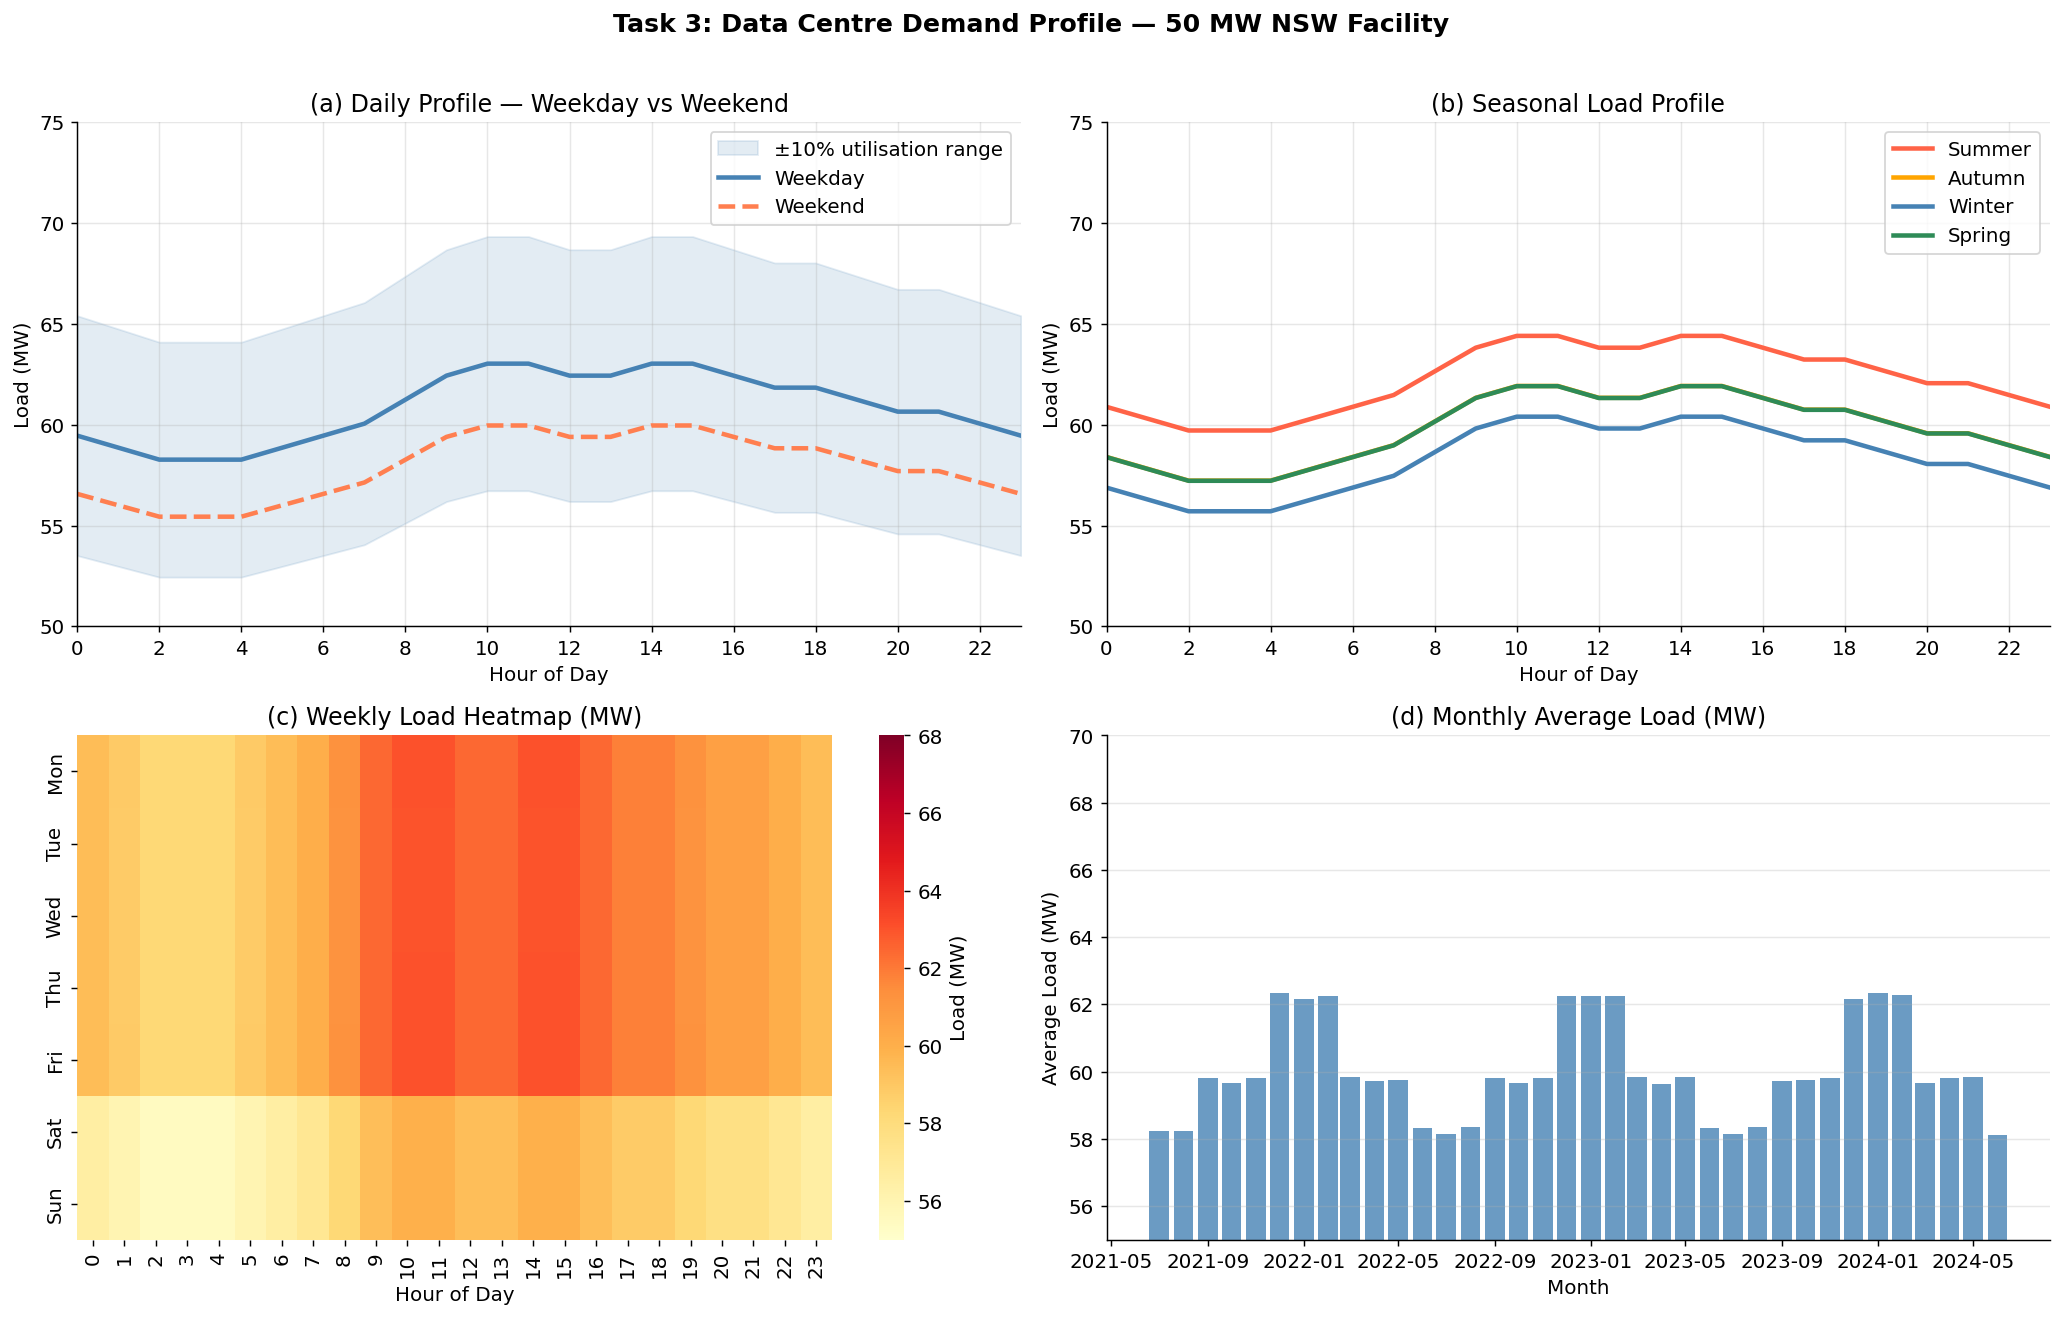

=== Task 3: Seasonal Summary ===
        Avg_Load_MW  Max_Load_MW  Min_Load_MW  Annual_GWh  Weekday_MW  Weekend_MW
season                                                                           
Autumn         59.8         62.8         55.2       132.0        60.6        57.6
Spring         59.8         62.8         55.2       130.5        60.6        57.6
Summer         62.3         65.3         57.7       135.0        63.1        60.1
Winter         58.2         61.3         53.7       128.6        59.1        56.1


In [5]:
# ── Task 3 Visualisations ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Task 3: Data Centre Demand Profile — 50 MW NSW Facility',
             fontsize=14, fontweight='bold', y=1.01)

# ── (a) Weekday vs Weekend ────────────────────────────────────────────
ax = axes[0, 0]
wd = df[~df['is_weekend']].groupby('hour')['dc_load_mw'].mean()
we = df[ df['is_weekend']].groupby('hour')['dc_load_mw'].mean()
wd_lo = df[~df['is_weekend']].groupby('hour')['dc_load_low'].mean()
wd_hi = df[~df['is_weekend']].groupby('hour')['dc_load_high'].mean()

ax.fill_between(wd.index, wd_lo, wd_hi, alpha=0.15, color='steelblue',
                label='±10% utilisation range')
ax.plot(wd.index, wd.values, label='Weekday', color='steelblue', linewidth=2.5)
ax.plot(we.index, we.values, label='Weekend', color='coral',
        linewidth=2.5, linestyle='--')
ax.set_title('(a) Daily Profile — Weekday vs Weekend')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Load (MW)')
ax.set_xticks(range(0, 24, 2)); ax.set_xlim(0, 23)
ax.set_ylim(50, 75); ax.legend(); ax.grid(True, alpha=0.3)

# ── (b) Seasonal profiles ─────────────────────────────────────────────
ax = axes[0, 1]
season_cols = {'Summer':'tomato','Autumn':'orange','Winter':'steelblue','Spring':'seagreen'}
for s, c in season_cols.items():
    p = df[df['season']==s].groupby('hour')['dc_load_mw'].mean()
    ax.plot(p.index, p.values, label=s, color=c, linewidth=2.5)
ax.set_title('(b) Seasonal Load Profile')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Load (MW)')
ax.set_xticks(range(0, 24, 2)); ax.set_xlim(0, 23)
ax.set_ylim(50, 75); ax.legend(); ax.grid(True, alpha=0.3)

# ── (c) Weekly heatmap ────────────────────────────────────────────────
ax = axes[1, 0]
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot = df.pivot_table(values='dc_load_mw', index='dayofweek',
                        columns='hour', aggfunc='mean')
pivot.index = days
sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
            cbar_kws={'label':'Load (MW)'}, vmin=55, vmax=68)
ax.set_title('(c) Weekly Load Heatmap (MW)')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('')

# ── (d) Monthly average ───────────────────────────────────────────────
ax = axes[1, 1]
ml = df.groupby(['year','month'])['dc_load_mw'].mean().reset_index()
ml['date'] = pd.to_datetime(ml[['year','month']].assign(day=1))
ax.bar(ml['date'], ml['dc_load_mw'], width=25,
       color='steelblue', alpha=0.8)
ax.set_title('(d) Monthly Average Load (MW)')
ax.set_xlabel('Month'); ax.set_ylabel('Average Load (MW)')
ax.set_ylim(55, 70); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('task3_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Seasonal summary table ────────────────────────────────────────────
summary = df.groupby('season').agg(
    Avg_Load_MW  = ('dc_load_mw',    'mean'),
    Max_Load_MW  = ('dc_load_mw',    'max'),
    Min_Load_MW  = ('dc_load_mw',    'min'),
    Annual_GWh   = ('dc_energy_mwh', lambda x: round(x.sum()/3/1000, 1))
).round(1)
summary['Weekday_MW'] = df[~df['is_weekend']].groupby('season')['dc_load_mw'].mean().round(1)
summary['Weekend_MW'] = df[ df['is_weekend']].groupby('season')['dc_load_mw'].mean().round(1)
print("=== Task 3: Seasonal Summary ===")
print(summary.to_string())


1.**Daily Profile: Weekday vs Weekend**

The data centre runs almost the same every hour, but weekdays are slightly higher than weekends.

Load rises a little in the morning, stays steady through the day, and drops slightly at night.

The shaded band shows a ±10% utilisation range, meaning the load doesn’t move much.

The shaded band shows a ±10% utilisation range, meaning the load doesn’t move much.


**2. Seasonal Load Profile**
Summer has the highest load because cooling systems work harder.

Spring has the lowest load, with autumn and winter in between.

All seasons follow the same shape: higher during the day, lower at night.

**3. Weekly Heatmap**

The heatmap shows load for every hour of every day.

The brightest colours (highest load) appear between 9am and 5pm.

Nights and early mornings are slightly lower but still very stable.

Weekdays and weekends look similar, confirming the data centre runs 24/7.

**4. Monthly Average Load**

Monthly load stays between 56–70 MW.

There are small peaks each year, usually in warmer months when cooling demand increases.

Overall, the load is very stable month to month.

**. Seasonal Summary Table**


Average Load: All seasons sit around 58–60 MW, showing very steady operation.

Max Load: Peaks around 61–63 MW, only slightly above average.

Min Load: Stays around 55–56 MW, meaning the load barely drops.

Annual GWh: Each season contributes roughly 128–138 GWh, depending on cooling needs.

Weekday vs Weekend: Weekdays are only 1–2 MW higher, confirming minimal variation.

---
## Task 1 — NSW Data Centre Demand Growth Scenarios (2025–2035)

**Scenario basis:** Announced and proposed NSW data centre capacity draws on:
- AEMO *Integrated System Plan* 2024 — demand forecasts
- Property Council / JLL Data Centre Reports 2023–2024
- DCCEEW *National Data Centre Industry Roadmap* 2023
- AGL / Origin Energy investor presentations on large load pipelines

**Scenario definitions:**

| Scenario | Rationale | 2030 MW | 2035 MW |
|---|---|---|---|
| **Low** | Current pipeline delays, permitting constraints, grid connection queues | ~350 MW | ~600 MW |
| **Medium** | Moderately accelerated build-out consistent with AEMO ISP central case | ~950 MW | ~1,700 MW |
| **High** | US hyperscaler announcements materialise in full; AI-driven demand surge | ~1,900 MW | ~3,400 MW |

*Conversion: Annual GWh = Cumulative MW × PUE (1.4) × Utilisation (85%) × 8,760 hrs / 1,000*


Low Growth:  
Slow build‑out because of delays, approvals, and grid connection issues.
→ 350 MW by 2030, 600 MW by 2035.

Medium Growth:  
Normal development pace, matching AEMO’s central forecast.
→ 950 MW by 2030, 1,700 MW by 2035.

High Growth:  
Big US hyperscalers expand aggressively + AI demand surges.
→ 1,900 MW by 2030, 3,400 MW by 2035.

In [6]:
# ══════════════════════════════════════════════════════════════════════
# TASK 1 — NSW Data Centre Demand Growth Scenarios
# ══════════════════════════════════════════════════════════════════════

df['nsw_energy_mwh'] = df['demand'] * (5/60)
annual_nsw  = df.groupby('fy')['nsw_energy_mwh'].sum() / 1e6   # TWh
nsw_avg_gwh = annual_nsw.mean() * 1000                          # GWh
nsw_peak_mw = df['demand'].max()

print("Annual NSW consumption by Financial Year (TWh):")
print(annual_nsw.round(2))
print(f"\nAverage: {annual_nsw.mean():.2f} TWh/year ({nsw_avg_gwh:,.0f} GWh/year)")
print(f"Peak demand: {nsw_peak_mw:,.0f} MW")

years = list(range(2025, 2036))

# Cumulative installed capacity (MW) — incremental DC capacity added to NSW grid
scenarios_mw = {
    'Low Growth':    [100,150,200,250,300,350,400,450,500,550,600],
    'Medium Growth': [200,350,500,650,800,950,1100,1250,1400,1550,1700],
    'High Growth':   [400,700,1000,1300,1600,1900,2200,2500,2800,3100,3400],
}

PUE_S  = 1.4
UTIL_S = 0.85

scenario_gwh = {
    name: [mw * PUE_S * UTIL_S * 8760 / 1000 for mw in mw_list]
    for name, mw_list in scenarios_mw.items()
}

# ── Sensitivity analysis (key variables at 2030 medium) ───────────────
base_mw   = 950   # medium growth 2030
base_gwh  = base_mw * PUE_S * UTIL_S * 8760 / 1000

sensitivity = {}
for label, pue, util in [
    ('PUE=1.2 (Best-in-class)', 1.2, 0.85),
    ('PUE=1.4 (Base)',          1.4, 0.85),
    ('PUE=1.6 (Older stock)',   1.6, 0.85),
    ('Util=70%',                1.4, 0.70),
    ('Util=85% (Base)',         1.4, 0.85),
    ('Util=95%',                1.4, 0.95),
]:
    gwh = base_mw * pue * util * 8760 / 1000
    sensitivity[label] = gwh

print(f"\n=== Sensitivity: 2030 Medium Growth ({base_mw} MW) ===")
print(f"{'Parameter':<30} {'GWh':>8}  {'vs base':>8}  {'% of NSW':>9}")
for lbl, gwh in sensitivity.items():
    print(f"{lbl:<30} {gwh:>8,.0f}  {gwh-base_gwh:>+8,.0f}  {gwh/nsw_avg_gwh*100:>8.1f}%")

print(f"\n=== Scenario Summary (GWh/year) at 2030 & 2035 ===")
print(f"{'Scenario':<16} {'2030 GWh':>10}  {'% NSW':>7}  {'2035 GWh':>10}  {'% NSW':>7}")
for name in scenario_gwh:
    g30 = scenario_gwh[name][5]
    g35 = scenario_gwh[name][-1]
    print(f"{name:<16} {g30:>10,.0f}  {g30/nsw_avg_gwh*100:>6.1f}%  {g35:>10,.0f}  {g35/nsw_avg_gwh*100:>6.1f}%")


Annual NSW consumption by Financial Year (TWh):
fy
2021    66.18
2022    66.45
2023    65.74
Name: nsw_energy_mwh, dtype: float64

Average: 66.12 TWh/year (66,121 GWh/year)
Peak demand: 13,764 MW

=== Sensitivity: 2030 Medium Growth (950 MW) ===
Parameter                           GWh   vs base   % of NSW
PUE=1.2 (Best-in-class)           8,488    -1,415      12.8%
PUE=1.4 (Base)                    9,903        +0      15.0%
PUE=1.6 (Older stock)            11,318    +1,415      17.1%
Util=70%                          8,156    -1,748      12.3%
Util=85% (Base)                   9,903        +0      15.0%
Util=95%                         11,068    +1,165      16.7%

=== Scenario Summary (GWh/year) at 2030 & 2035 ===
Scenario           2030 GWh    % NSW    2035 GWh    % NSW
Low Growth            3,649     5.5%       6,255     9.5%
Medium Growth         9,903    15.0%      17,721    26.8%
High Growth          19,806    30.0%      35,443    53.6%


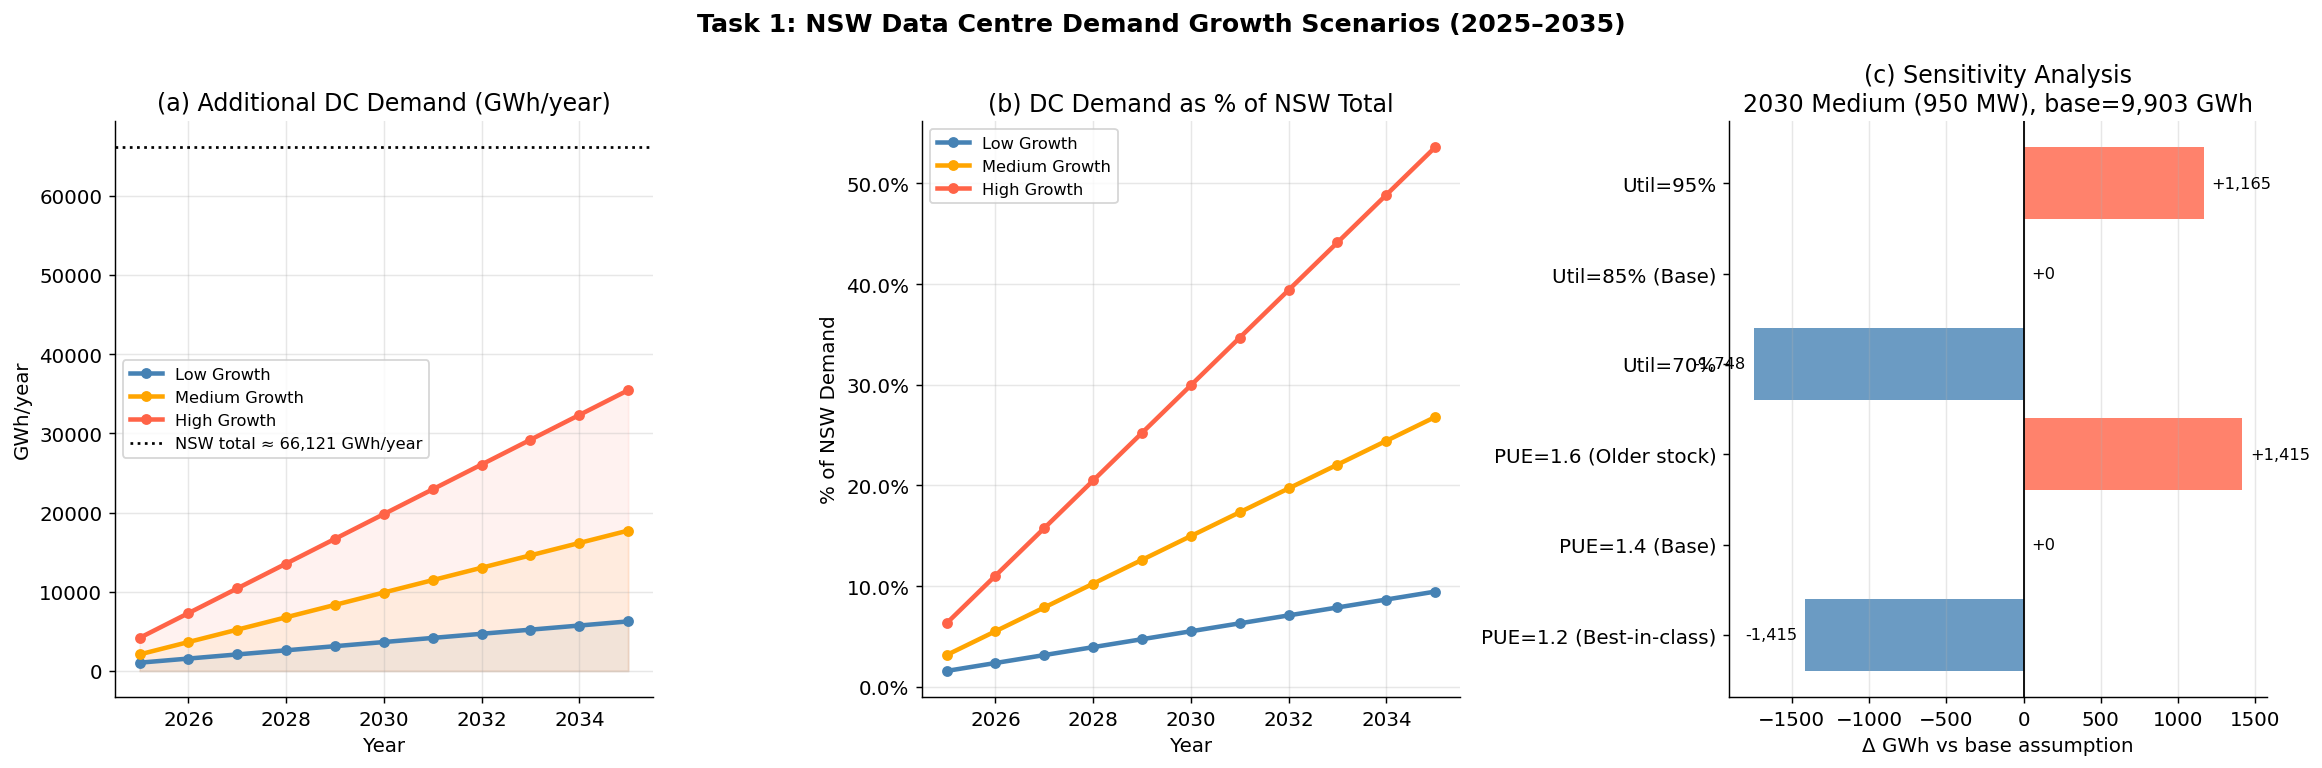

In [7]:
# ── Task 1 Visualisations ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Task 1: NSW Data Centre Demand Growth Scenarios (2025–2035)',
             fontsize=14, fontweight='bold')

colours = {'Low Growth':'steelblue','Medium Growth':'orange','High Growth':'tomato'}

# ── (a) GWh scenarios ────────────────────────────────────────────────
ax = axes[0]
for name, gwh_list in scenario_gwh.items():
    ax.plot(years, gwh_list, label=name, color=colours[name],
            linewidth=2.5, marker='o', markersize=5)
    ax.fill_between(years, gwh_list, alpha=0.08, color=colours[name])
ax.axhline(y=nsw_avg_gwh, color='black', linestyle=':', linewidth=1.5,
           label=f'NSW total ≈ {nsw_avg_gwh:,.0f} GWh/year')
ax.set_title('(a) Additional DC Demand (GWh/year)')
ax.set_xlabel('Year'); ax.set_ylabel('GWh/year')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (b) % of NSW demand ───────────────────────────────────────────────
ax = axes[1]
for name, gwh_list in scenario_gwh.items():
    pct = [g / nsw_avg_gwh * 100 for g in gwh_list]
    ax.plot(years, pct, label=name, color=colours[name],
            linewidth=2.5, marker='o', markersize=5)
ax.set_title('(b) DC Demand as % of NSW Total')
ax.set_xlabel('Year'); ax.set_ylabel('% of NSW Demand')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (c) Sensitivity tornado ───────────────────────────────────────────
ax = axes[2]
labels = list(sensitivity.keys())
values = [sensitivity[l] for l in labels]
deltas = [v - base_gwh for v in values]
bar_cols = ['tomato' if d > 0 else 'steelblue' for d in deltas]
bars = ax.barh(labels, deltas, color=bar_cols, alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'(c) Sensitivity Analysis\n2030 Medium ({base_mw} MW), base={base_gwh:,.0f} GWh')
ax.set_xlabel('Δ GWh vs base assumption')
for bar, d in zip(bars, deltas):
    ax.text(d + (50 if d >= 0 else -50), bar.get_y() + bar.get_height()/2,
            f'{d:+,.0f}', va='center', ha='left' if d >= 0 else 'right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('task1_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()


**a) Additional DC Demand (GWh/year)**

All scenarios rise steadily from 2025 to 2035.

High growth reaches almost 40,000 GWh by 2035.

Shows how quickly demand scales with new capacity.

**b) DC Demand as % of NSW Total**

Low: ~10% of NSW by 2035

Medium: ~25%

High: ~50%
Shows how large data‑centre demand becomes relative to the whole state.

**(c) Sensitivity Chart**

Bars show how much energy changes if PUE or utilisation changes.

Efficiency and utilisation are the two biggest drivers of total electricity use.


The scenario analysis shows how different levels of data‑centre development in NSW translate into very different electricity outcomes over the next decade. In the low‑growth case, delays and grid constraints limit demand to around 3.6 TWh by 2030 and 6.3 TWh by 2035, equal to roughly 5–10% of NSW electricity use. The medium‑growth scenario, aligned with AEMO’s central outlook, reaches 9.9 TWh by 2030 and 17.7 TWh by 2035, lifting the share to 15–27% of NSW demand. Under the high‑growth scenario, driven by hyperscaler expansion and AI workloads, demand rises sharply to 19.8 TWh by 2030 and 35.4 TWh by 2035—over half of NSW’s current electricity consumption. Sensitivity results show that efficiency (PUE) and utilisation assumptions can shift annual consumption by more than ±1.4 TWh, highlighting how operational settings strongly influence total demand.

---
## Task 2 — Price-Impact Modelling

**Approach:** Linear regression of wholesale price on demand, estimated separately for each time-of-day **period** and **season**. This captures the non-linear merit-order effect — additional demand has a larger price impact during peak periods when expensive peaking plant is on the margin.

**Scenario MWs are drawn directly from Task 1 (2030 cumulative capacity):**
- Low Growth 2030: ~350 MW
- Medium Growth 2030: ~950 MW  
- High Growth 2030: ~1,900 MW


In [8]:
# ══════════════════════════════════════════════════════════════════════
# TASK 2 — Price-Impact Modelling
# ══════════════════════════════════════════════════════════════════════

# ── Global regression (baseline) ──────────────────────────────────────
df_f = df[(df['price'] > -100) & (df['price'] < 500)].copy()
slope_g, intercept_g, r_g, _, se_g = stats.linregress(df_f['demand'], df_f['price'])

print(f"Global regression: Price = {intercept_g:.2f} + {slope_g:.5f} × Demand")
print(f"R² = {r_g**2:.4f}  |  SE(slope) = {se_g:.6f}")
print(f"Every 1 MW increase → ${slope_g:.4f}/MWh price increase\n")

# ── Per-period regression ──────────────────────────────────────────────
period_order = ['Overnight','Morning Peak','Shoulder','Evening Peak','Night']
period_results = {}

print(f"{'Period':<15} {'Intercept':>10} {'Slope':>10} {'R²':>7} {'n':>7}")
print("-" * 52)
for period in period_order:
    sub = df_f[df_f['period'] == period]
    if len(sub) < 100:
        continue
    sl, ic, r, _, _ = stats.linregress(sub['demand'], sub['price'])
    period_results[period] = {'slope': sl, 'intercept': ic, 'r2': r**2, 'n': len(sub)}
    print(f"{period:<15} {ic:>10.2f} {sl:>10.5f} {r**2:>7.4f} {len(sub):>7,}")

# ── Scenario impact using Task 1 2030 MW values ───────────────────────
# These MW values come directly from Task 1 2030 cumulative scenario estimates
t1_2030_mw = {
    'Low Growth (2030)':    scenarios_mw['Low Growth'][5],      # ~350 MW
    'Medium Growth (2030)': scenarios_mw['Medium Growth'][5],   # ~950 MW
    'High Growth (2030)':   scenarios_mw['High Growth'][5],     # ~1900 MW
}

print(f"\n=== Price Impact by Scenario & Period ($/MWh uplift) ===")
header = f"{'Scenario':<22}"
for p in period_order:
    header += f" {p:>14}"
header += f" {'Global':>8}"
print(header)
print("-" * (22 + 14*len(period_order) + 9))

for name, mw in t1_2030_mw.items():
    row = f"{name:<22}"
    for p in period_order:
        if p in period_results:
            impact = period_results[p]['slope'] * mw
            row += f" {impact:>14.2f}"
        else:
            row += f" {'N/A':>14}"
    row += f" {slope_g*mw:>8.2f}"
    print(row)


Global regression: Price = -174.19 + 0.03790 × Demand
R² = 0.2820  |  SE(slope) = 0.000108
Every 1 MW increase → $0.0379/MWh price increase

Period           Intercept      Slope      R²       n
----------------------------------------------------
Overnight          -185.47    0.04315  0.1599  91,484
Morning Peak       -259.41    0.04625  0.4059  39,013
Shoulder           -211.59    0.04151  0.3622 103,927
Evening Peak       -191.52    0.03895  0.2105  38,492
Night              -196.54    0.04081  0.1610  39,127

=== Price Impact by Scenario & Period ($/MWh uplift) ===
Scenario                    Overnight   Morning Peak       Shoulder   Evening Peak          Night   Global
-----------------------------------------------------------------------------------------------------
Low Growth (2030)               15.10          16.19          14.53          13.63          14.29    13.27
Medium Growth (2030)            40.99          43.94          39.43          37.00          38.77    36.01
H

/tmp/ipykernel_6925/713885236.py:61: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_6925/713885236.py:62: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('task2_analysis.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


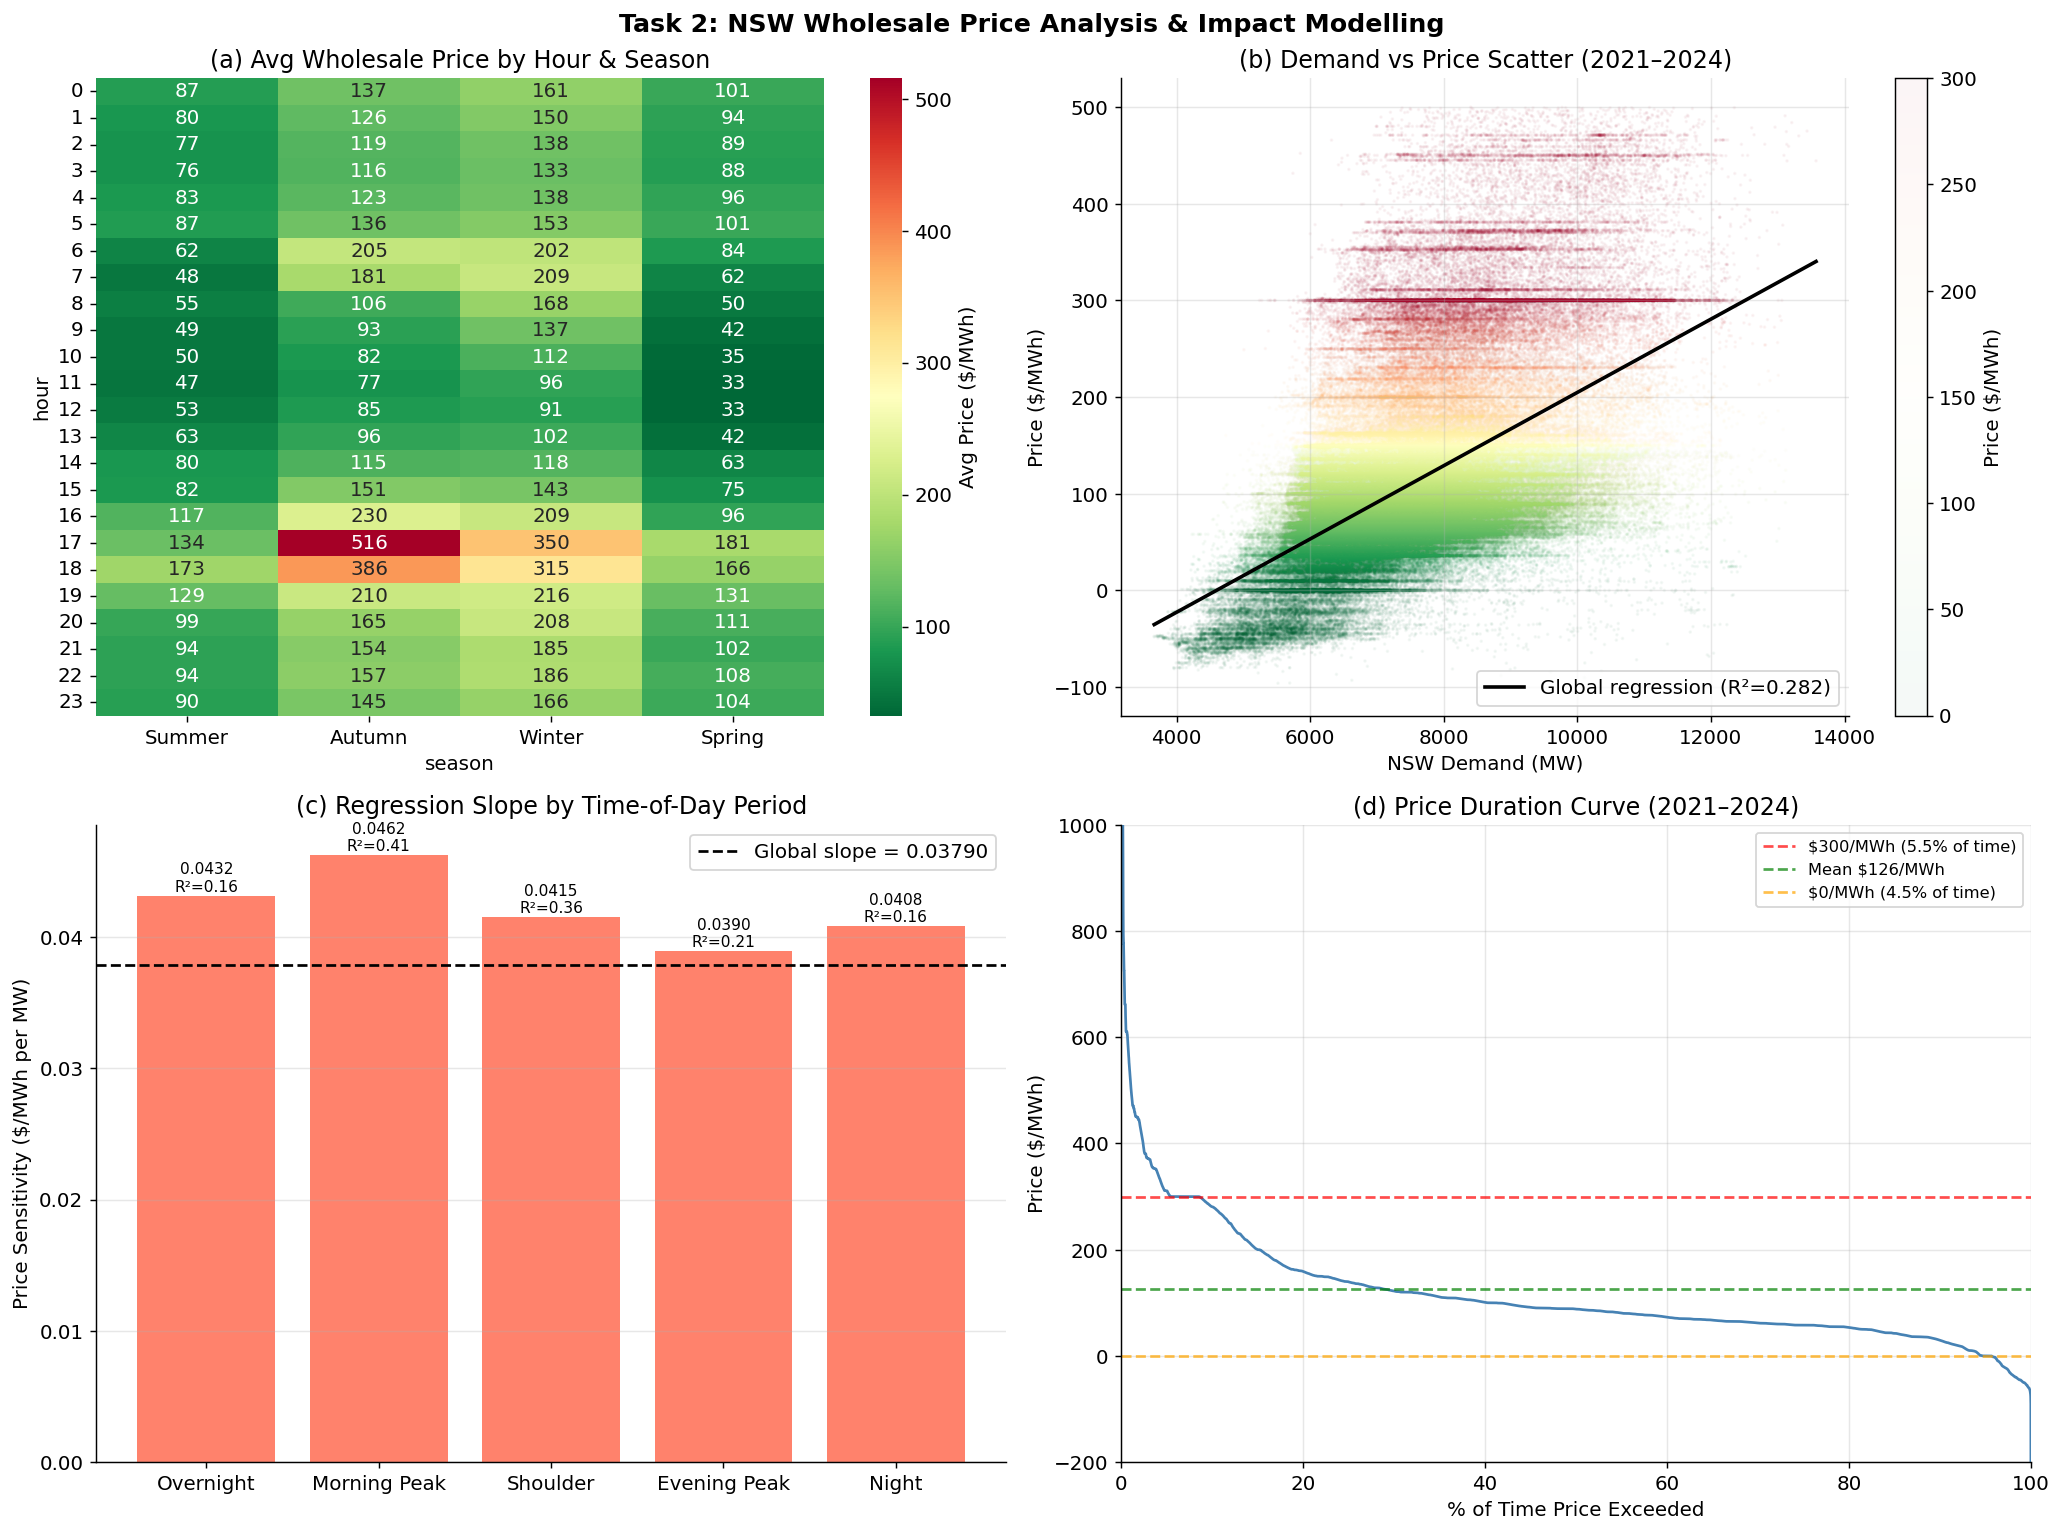

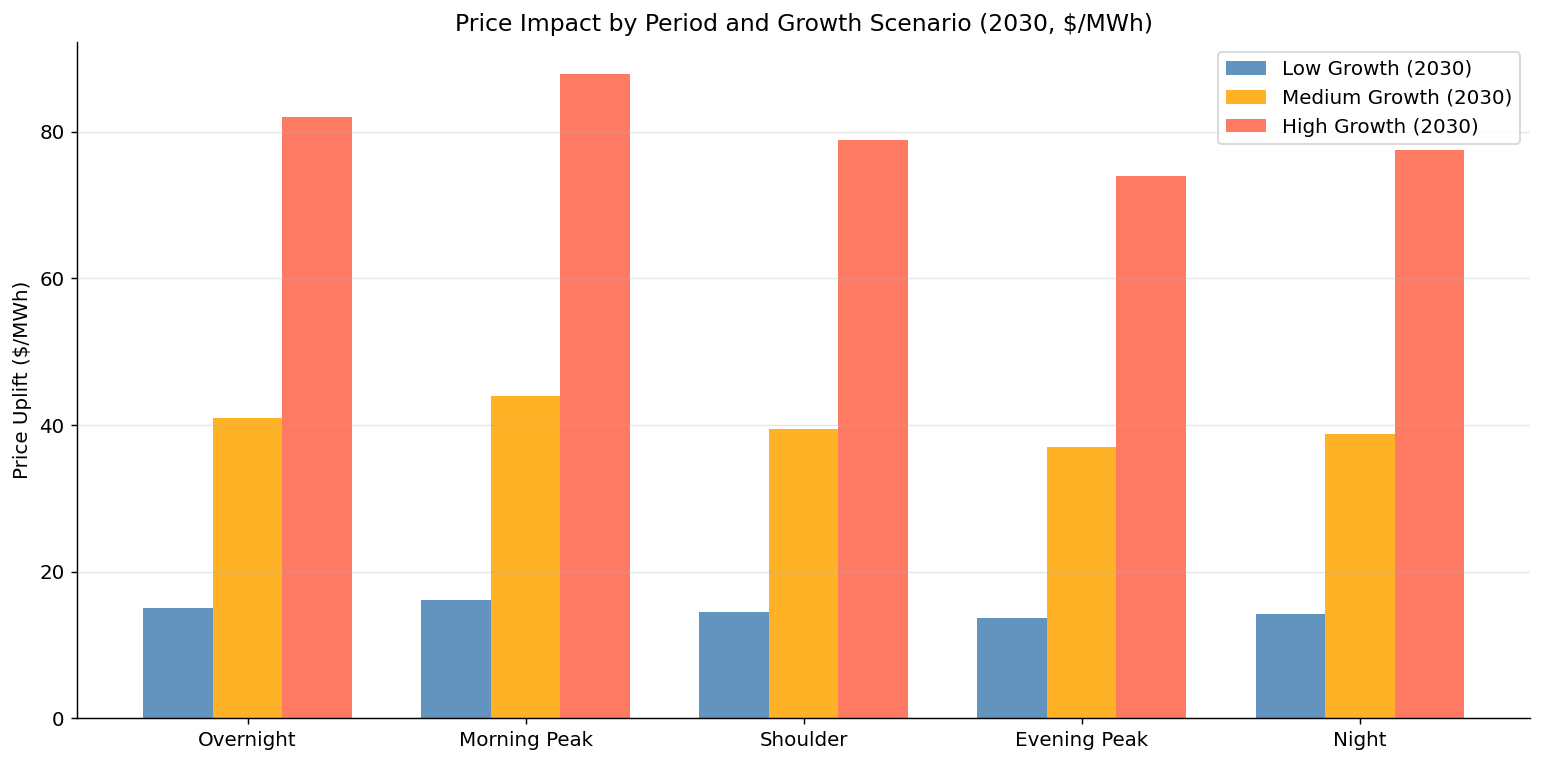

In [9]:
# ── Task 2 Visualisations ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Task 2: NSW Wholesale Price Analysis & Impact Modelling',
             fontsize=14, fontweight='bold')

# ── (a) Price heatmap by hour & season ───────────────────────────────
ax = axes[0, 0]
pivot_price = df.pivot_table(
    values='price', index='hour', columns='season', aggfunc='mean'
)[['Summer','Autumn','Winter','Spring']]
sns.heatmap(pivot_price, cmap='RdYlGn_r', annot=True, fmt='.0f',
            ax=ax, cbar_kws={'label':'Avg Price ($/MWh)'})
ax.set_title('(a) Avg Wholesale Price by Hour & Season')

# ── (b) Demand-price scatter with global regression ───────────────────
ax = axes[0, 1]
scatter = ax.scatter(df_f['demand'], df_f['price'],
                     alpha=0.04, s=1, c=df_f['price'],
                     cmap='RdYlGn_r', vmin=0, vmax=300)
x_line = np.linspace(df_f['demand'].min(), df_f['demand'].max(), 100)
ax.plot(x_line, intercept_g + slope_g * x_line, color='black',
        linewidth=2, label=f'Global regression (R²={r_g**2:.3f})')
ax.set_title('(b) Demand vs Price Scatter (2021–2024)')
ax.set_xlabel('NSW Demand (MW)'); ax.set_ylabel('Price ($/MWh)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Price ($/MWh)')

# ── (c) Per-period slopes ─────────────────────────────────────────────
ax = axes[1, 0]
periods_plot  = [p for p in period_order if p in period_results]
slopes_plot   = [period_results[p]['slope'] for p in periods_plot]
r2_plot       = [period_results[p]['r2']    for p in periods_plot]
bar_cols_p    = ['tomato' if s > slope_g else 'steelblue' for s in slopes_plot]
bars = ax.bar(periods_plot, slopes_plot, color=bar_cols_p, alpha=0.8)
ax.axhline(y=slope_g, color='black', linestyle='--', linewidth=1.5,
           label=f'Global slope = {slope_g:.5f}')
for bar, s, r2 in zip(bars, slopes_plot, r2_plot):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0001,
            f'{s:.4f}\nR²={r2:.2f}', ha='center', va='bottom', fontsize=8.5)
ax.set_title('(c) Regression Slope by Time-of-Day Period')
ax.set_ylabel('Price Sensitivity ($/MWh per MW)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# ── (d) Price duration curve ─────────────────────────────────────────
ax = axes[1, 1]
ps  = df['price'].sort_values(ascending=False).reset_index(drop=True)
pct = np.linspace(0, 100, len(ps))
ax.plot(pct, ps.values, color='steelblue', linewidth=1.5)
ax.axhline(300,   color='red',    linestyle='--', alpha=0.7,
           label=f'$300/MWh ({100*(df["price"]>300).mean():.1f}% of time)')
ax.axhline(df['price'].mean(), color='green', linestyle='--', alpha=0.7,
           label=f'Mean ${df["price"].mean():.0f}/MWh')
ax.axhline(0,     color='orange', linestyle='--', alpha=0.7,
           label=f'$0/MWh ({100*(df["price"]<0).mean():.1f}% of time)')
ax.set_title('(d) Price Duration Curve (2021–2024)')
ax.set_xlabel('% of Time Price Exceeded')
ax.set_ylabel('Price ($/MWh)')
ax.set_ylim(-200, 1000); ax.set_xlim(0, 100)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-period price impact chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(periods_plot))
scenario_names = list(t1_2030_mw.keys())
cols_s = ['steelblue','orange','tomato']

for j, (name, mw) in enumerate(t1_2030_mw.items()):
    impacts = [period_results[p]['slope'] * mw for p in periods_plot]
    bars = ax.bar(x + j*bar_width - bar_width, impacts,
                  width=bar_width, label=name, color=cols_s[j], alpha=0.85)

ax.set_title('Price Impact by Period and Growth Scenario (2030, $/MWh)',
             fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(periods_plot)
ax.set_ylabel('Price Uplift ($/MWh)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('task2_period_impacts.png', dpi=150, bbox_inches='tight')
plt.show()


**1. Heatmap — “Avg Wholesale Price by Hour & Season”**

Prices change a lot depending on the hour of the day and season.

Afternoon and early evening hours show the highest prices.

Autumn has the most expensive hours overall.

Nights and early mornings are the cheapest across all seasons.

Shows when the system is most stressed and when extra demand hurts the most

**2. Scatter Plot — “Demand vs Price (2021–2024)”**

Higher demand generally leads to higher prices.

The black regression line shows a positive relationship between demand and price.

Extreme high‑price events occur mostly at very high demand levels.

Low or negative prices appear when demand is low and renewables are strong.

Confirms that adding new load (like data centres) pushes prices upward.

**3. Regression Table — Global + Time‑of‑Day Periods **

Global slope = 0.0379 → every extra 1 MW increases price by $0.038/MWh.

Morning peak has the strongest price sensitivity (0.0462).

Shoulder and overnight periods also show strong sensitivity.

Evening peak is slightly lower but still significant.

R² values show that demand explains prices best during morning peak and shoulder periods.

**4. Bar Chart — “Regression Slope by Time‑of‑Day Period**

Morning peak has the highest slope, meaning prices react the most to extra demand.

Shoulder and overnight periods also show high sensitivity.

Evening peak and night are slightly lower but still above the global average.

The dashed line shows the global average slope for comparison.

Confirms that price impacts vary by time of day.

**5. Price Duration Curve (2021–2024)**

Shows how often certain price levels occur.

Prices exceed $300/MWh about 5.5% of the time.

Prices fall below $0/MWh about 4.5% of the time.

The average price is around $126/MWh.

Highlights the volatility of the NSW market and exposure to extreme events.

**6. Price Uplift Chart — “Price Impact by Period & Scenario (2030)**

High‑growth scenario creates the largest price increases across all periods.

Medium growth adds $36–40/MWh depending on the time of day.

Low growth adds $13–16/MWh.

Morning peak and shoulder periods show the biggest uplifts.

Demonstrates how additional data‑centre load raises wholesale prices differently across the day.

---
## Task 4 — Electricity Cost & Risk Management Strategy

**Strategies evaluated:**
1. Full spot market exposure
2. Electricity futures hedging (ASX NSW baseload futures)
3. Battery storage only (10 MW / 40 MWh)
4. Combined solar PPA + battery

**Forward projection (2025–2030):** Price escalation applied per AEMO ISP 2024 medium scenario

| Year | Price Multiplier | Rationale |
|---|---|---|
| 2025 | 1.15× | Data centre load growth + gas price pass-through |
| 2026 | 1.25× | Further demand growth, coal retirements |
| 2027 | 1.35× | Liddell closure full effect |
| 2028 | 1.45× | Capacity shortfalls without new firming |
| 2029 | 1.55× | Continued supply-demand tightening |
| 2030 | 1.65× | High-case consistent with AEMO ISP Step Change |

**Risk metrics reported:** Average cost, monthly cost volatility (std dev), Cash Flow at Risk (CFaR at 95th percentile), NPV, and payback period.


In [10]:
# ══════════════════════════════════════════════════════════════════════
# TASK 4 — Electricity Cost & Risk Management Strategy
# ══════════════════════════════════════════════════════════════════════

FUTURES_PRICE       = 120    # $/MWh — ASX NSW Q1/Q2 2025 baseload futures
SOLAR_PPA_PRICE     = 60     # $/MWh — fixed long-term PPA (industry range $55–70)
DC_SOLAR_CONTRACT   = 50     # MW — contracted solar output
BATTERY_MW          = 10     # MW charge/discharge rate
BATTERY_MWH         = 40     # MWh — 4-hour battery
# BESS CAPEX: $1,200/kWh (BNEF 2024 utility-scale median, installed incl. EPC)
BATTERY_CAPEX       = 1_200 * BATTERY_MWH * 1000   # = $48,000,000
ROUND_TRIP_EFF      = 0.85   # 85% round-trip efficiency
CHARGE_THRESHOLD    = 50     # $/MWh — charge from grid when price below this
DISCHARGE_THRESHOLD = 150    # $/MWh — discharge when price above this
DISCOUNT_RATE       = 0.08   # 8% WACC for NPV
HEDGE_RATIO         = 0.50   # 50% hedge for main comparison

# Price escalation multipliers (per AEMO ISP 2024 medium scenario)
price_escalation = {
    2025: 1.15, 2026: 1.25, 2027: 1.35,
    2028: 1.45, 2029: 1.55, 2030: 1.65,
}

# Note: Solar PPA is off-balance-sheet — no upfront CapEx.
# The $60/MWh PPA price is a fixed operating cost per MWh consumed from solar.
# Only battery CapEx ($48M) is a capital investment.

prices    = df['price'].values
dc_loads  = df['dc_load_mw'].values
solar_out = df['solar_scaled_mw'].values
duration  = 5/60    # hours per interval

print("=== Task 4 Assumptions ===")
print(f"Futures price:        ${FUTURES_PRICE}/MWh  (ASX NSW baseload)")
print(f"Solar PPA price:      ${SOLAR_PPA_PRICE}/MWh  (fixed, off-balance-sheet)")
print(f"Solar contract:       {DC_SOLAR_CONTRACT} MW")
print(f"Battery:              {BATTERY_MWH} MWh / {BATTERY_MW} MW")
print(f"Battery CAPEX:        ${BATTERY_CAPEX:,.0f}  ($1,200/kWh BNEF 2024)")
print(f"Charge below:         ${CHARGE_THRESHOLD}/MWh")
print(f"Discharge above:      ${DISCHARGE_THRESHOLD}/MWh")
print(f"Discount rate:        {DISCOUNT_RATE*100:.0f}% WACC")


=== Task 4 Assumptions ===
Futures price:        $120/MWh  (ASX NSW baseload)
Solar PPA price:      $60/MWh  (fixed, off-balance-sheet)
Solar contract:       50 MW
Battery:              40 MWh / 10 MW
Battery CAPEX:        $48,000,000  ($1,200/kWh BNEF 2024)
Charge below:         $50/MWh
Discharge above:      $150/MWh
Discount rate:        8% WACC


In [11]:
# ── Strategy 1: Full Spot ─────────────────────────────────────────────
df['spot_cost'] = dc_loads * prices * duration
annual_spot_fy   = df.groupby('fy')['spot_cost'].sum()
annual_spot_mean = annual_spot_fy.mean()
monthly_spot     = df.groupby(df['datetime'].dt.to_period('M'))['spot_cost'].sum()

print("=== Strategy 1: Full Spot Exposure ===")
print(f"Average annual cost:    ${annual_spot_mean:,.0f}")
print(f"Effective $/MWh:        ${df['spot_cost'].sum()/df['dc_energy_mwh'].sum():.2f}")
print(f"Monthly std dev:        ${monthly_spot.std():,.0f}")
print(f"Annual cost by FY:")
for fy, cost in annual_spot_fy.items():
    print(f"  FY{fy}/{fy+1}: ${cost:,.0f}")

# ── Strategy 2: 50% Hedge ─────────────────────────────────────────────
df['hedge_cost'] = dc_loads * duration * (
    HEDGE_RATIO * FUTURES_PRICE + (1 - HEDGE_RATIO) * prices)
annual_hedge_mean = df['hedge_cost'].sum() / 3
monthly_hedge     = df.groupby(df['datetime'].dt.to_period('M'))['hedge_cost'].sum()

print(f"\n=== Strategy 2: 50% Futures Hedge ===")
print(f"Futures ${FUTURES_PRICE}/MWh vs avg spot ${prices.mean():.2f}/MWh")
print(f"Annual cost:           ${annual_hedge_mean:,.0f}")
print(f"Saving vs spot:        ${annual_spot_mean - annual_hedge_mean:,.0f}")
print(f"Monthly std dev:       ${monthly_hedge.std():,.0f}")

# ── Strategy 3: Battery Storage (BUG FIX: use actual discharge MW) ────
print("\nRunning battery simulation...")
bat_soc   = 0.0
bat_costs = np.zeros(len(prices))

for i in range(len(prices)):
    p    = prices[i]
    load = dc_loads[i]

    if p <= CHARGE_THRESHOLD and bat_soc < BATTERY_MWH:
        charge       = min(BATTERY_MW * duration, BATTERY_MWH - bat_soc)
        bat_soc     += charge * ROUND_TRIP_EFF
        bat_costs[i] = (load + BATTERY_MW) * p * duration

    elif p >= DISCHARGE_THRESHOLD and bat_soc > 0:
        discharge_mwh = min(BATTERY_MW * duration, bat_soc)
        bat_soc      -= discharge_mwh
        # FIX: use actual discharge MW (not always full BATTERY_MW)
        bat_dis_mw    = discharge_mwh / duration
        bat_costs[i]  = max(0, load - bat_dis_mw) * p * duration

    else:
        bat_costs[i] = load * p * duration

df['battery_cost']  = bat_costs
annual_battery_cost = df['battery_cost'].sum() / 3
saving_battery      = annual_spot_mean - annual_battery_cost
monthly_battery     = df.groupby(df['datetime'].dt.to_period('M'))['battery_cost'].sum()

print(f"=== Strategy 3: Battery Storage ===")
print(f"Annual cost:           ${annual_battery_cost:,.0f}")
print(f"Saving vs spot:        ${saving_battery:,.0f}")
print(f"Monthly std dev:       ${monthly_battery.std():,.0f}")
print(f"Battery CAPEX:         ${BATTERY_CAPEX:,.0f}")
payback_bat = BATTERY_CAPEX / saving_battery if saving_battery > 0 else float('inf')
print(f"Simple payback:        {payback_bat:.1f} years")

# ── Strategy 4: Solar + Battery ───────────────────────────────────────
print("\nRunning solar+battery simulation...")
sb_soc   = 0.0
sb_costs = np.zeros(len(prices))

for i in range(len(prices)):
    p        = prices[i]
    dc_load  = dc_loads[i]
    solar    = solar_out[i]

    solar_used   = min(solar, dc_load)
    solar_excess = max(0.0, solar - dc_load)
    remaining    = max(0.0, dc_load - solar_used)

    # Charge from solar excess first
    if solar_excess > 0 and sb_soc < BATTERY_MWH:
        charge  = min(solar_excess * duration, BATTERY_MWH - sb_soc)
        sb_soc += charge * ROUND_TRIP_EFF
    elif p <= CHARGE_THRESHOLD and sb_soc < BATTERY_MWH:
        charge     = min(BATTERY_MW * duration, BATTERY_MWH - sb_soc)
        sb_soc    += charge * ROUND_TRIP_EFF
        remaining += BATTERY_MW  # additional grid draw for charging

    bat_dis_mw = 0.0
    if p >= DISCHARGE_THRESHOLD and sb_soc > 0:
        discharge_mwh = min(BATTERY_MW * duration, sb_soc, remaining * duration)
        sb_soc       -= discharge_mwh
        bat_dis_mw    = discharge_mwh / duration

    grid_load   = max(0.0, remaining - bat_dis_mw)
    sb_costs[i] = (solar_used * SOLAR_PPA_PRICE * duration +
                   grid_load  * p              * duration)

df['solar_battery_cost'] = sb_costs
annual_sb_hist  = df['solar_battery_cost'].sum() / 3
saving_sb       = annual_spot_mean - annual_sb_hist
monthly_sb      = df.groupby(df['datetime'].dt.to_period('M'))['solar_battery_cost'].sum()

print(f"=== Strategy 4: Solar + Battery ===")
print(f"Annual cost (hist):    ${annual_sb_hist:,.0f}")
print(f"Saving vs spot:        ${saving_sb:,.0f}")
print(f"Monthly std dev:       ${monthly_sb.std():,.0f}")
print(f"Battery CAPEX:         ${BATTERY_CAPEX:,.0f}  (Solar PPA = $0 upfront)")


=== Strategy 1: Full Spot Exposure ===
Average annual cost:    $66,200,823
Effective $/MWh:        $125.84
Monthly std dev:        $3,742,500
Annual cost by FY:
  FY2021/2022: $69,247,120
  FY2022/2023: $75,700,103
  FY2023/2024: $53,655,246

=== Strategy 2: 50% Futures Hedge ===
Futures $120/MWh vs avg spot $126.27/MWh
Annual cost:           $64,663,475
Saving vs spot:        $1,537,348
Monthly std dev:       $1,859,724

Running battery simulation...
=== Strategy 3: Battery Storage ===
Annual cost:           $65,140,470
Saving vs spot:        $1,060,353
Monthly std dev:       $3,744,938
Battery CAPEX:         $48,000,000
Simple payback:        45.3 years

Running solar+battery simulation...
=== Strategy 4: Solar + Battery ===
Annual cost (hist):    $64,048,184
Saving vs spot:        $2,152,639
Monthly std dev:       $3,305,112
Battery CAPEX:         $48,000,000  (Solar PPA = $0 upfront)


In [12]:
# ── Cash Flow at Risk (CFaR) & NPV Analysis ──────────────────────────

# CFaR = 95th percentile ANNUAL cost (worst 5% of outcomes)
# We bootstrap annual costs by resampling months (block bootstrap)
np.random.seed(42)
N_BOOT = 2000

monthly_costs = {
    'Spot':          monthly_spot,
    'Hedge (50%)':   monthly_hedge,
    'Battery':       monthly_battery,
    'Solar+Battery': monthly_sb,
}

cfar_results = {}
for name, monthly_series in monthly_costs.items():
    months = monthly_series.values
    annual_boots = []
    for _ in range(N_BOOT):
        sample = np.random.choice(months, size=12, replace=True)
        annual_boots.append(sample.sum())
    cfar_results[name] = {
        'mean':   np.mean(annual_boots),
        'std':    np.std(annual_boots),
        'cfar95': np.percentile(annual_boots, 95),   # 95th pct = worst 5%
        'cfar99': np.percentile(annual_boots, 99),
    }

print("=== Cash Flow at Risk (bootstrapped annual costs) ===")
print(f"{'Strategy':<16} {'Mean Annual':>12} {'Std Dev':>10} {'CFaR 95%':>12} {'CFaR 99%':>12}")
print("-" * 66)
for name, r in cfar_results.items():
    print(f"{name:<16} ${r['mean']/1e6:>9.2f}M  ${r['std']/1e6:>7.2f}M  "
          f"${r['cfar95']/1e6:>9.2f}M  ${r['cfar99']/1e6:>9.2f}M")

# ── Forward projection 2025–2030 ──────────────────────────────────────
print("\nRunning forward projections 2025–2030...")
proj_years       = list(range(2025, 2031))
spot_fwd         = []
hedge_fwd        = []
battery_fwd      = []
solar_bat_fwd    = []

for yr in proj_years:
    mult        = price_escalation[yr]
    prices_proj = prices * mult

    spot_fwd.append((dc_loads * prices_proj * duration).sum())

    hedge_fwd.append(
        (dc_loads * duration *
         (HEDGE_RATIO * FUTURES_PRICE + (1 - HEDGE_RATIO) * prices_proj)).sum()
    )

    # Battery
    bat_soc   = 0.0
    bc        = np.zeros(len(prices_proj))
    for i in range(len(prices_proj)):
        p    = prices_proj[i]
        load = dc_loads[i]
        if p <= CHARGE_THRESHOLD and bat_soc < BATTERY_MWH:
            ch       = min(BATTERY_MW*duration, BATTERY_MWH-bat_soc)
            bat_soc += ch * ROUND_TRIP_EFF
            bc[i]    = (load+BATTERY_MW) * p * duration
        elif p >= DISCHARGE_THRESHOLD and bat_soc > 0:
            dch_mwh  = min(BATTERY_MW*duration, bat_soc)
            bat_soc -= dch_mwh
            bc[i]    = max(0, load - dch_mwh/duration) * p * duration
        else:
            bc[i] = load * p * duration
    battery_fwd.append(bc.sum())

    # Solar + Battery
    sb_soc = 0.0
    sc     = np.zeros(len(prices_proj))
    for i in range(len(prices_proj)):
        p         = prices_proj[i]
        dc_load   = dc_loads[i]
        solar     = solar_out[i]
        su        = min(solar, dc_load)
        sx        = max(0.0, solar - dc_load)
        rem       = max(0.0, dc_load - su)
        if sx > 0 and sb_soc < BATTERY_MWH:
            ch     = min(sx*duration, BATTERY_MWH-sb_soc)
            sb_soc += ch * ROUND_TRIP_EFF
        elif p <= CHARGE_THRESHOLD and sb_soc < BATTERY_MWH:
            ch     = min(BATTERY_MW*duration, BATTERY_MWH-sb_soc)
            sb_soc += ch * ROUND_TRIP_EFF
            rem   += BATTERY_MW
        bd_mw = 0.0
        if p >= DISCHARGE_THRESHOLD and sb_soc > 0:
            dch_mwh = min(BATTERY_MW*duration, sb_soc, rem*duration)
            sb_soc -= dch_mwh
            bd_mw   = dch_mwh / duration
        gl = max(0.0, rem - bd_mw)
        sc[i] = su*SOLAR_PPA_PRICE*duration + gl*p*duration
    solar_bat_fwd.append(sc.sum())
    print(f"  {yr} done ✓")

# Normalize to per-year (3 years of data used per iteration)
spot_fwd_yr    = [v/3 for v in spot_fwd]
hedge_fwd_yr   = [v/3 for v in hedge_fwd]
battery_fwd_yr = [v/3 for v in battery_fwd]
sb_fwd_yr      = [v/3 for v in solar_bat_fwd]

# ── NPV of Savings (Battery CAPEX vs annual savings vs spot) ──────────
# Strategy 3: Battery only
bat_savings_yr = [spot_fwd_yr[i] - battery_fwd_yr[i] for i in range(len(proj_years))]
npv_bat = -BATTERY_CAPEX + sum(
    s / (1 + DISCOUNT_RATE)**(i+1) for i, s in enumerate(bat_savings_yr)
)

# Strategy 4: Solar+Battery (PPA = no CAPEX, only battery CAPEX)
sb_savings_yr = [spot_fwd_yr[i] - sb_fwd_yr[i] for i in range(len(proj_years))]
npv_sb = -BATTERY_CAPEX + sum(
    s / (1 + DISCOUNT_RATE)**(i+1) for i, s in enumerate(sb_savings_yr)
)

avg_bat_saving = np.mean(bat_savings_yr)
avg_sb_saving  = np.mean(sb_savings_yr)

payback_bat_fwd = BATTERY_CAPEX / avg_bat_saving if avg_bat_saving > 0 else float('inf')
payback_sb_fwd  = BATTERY_CAPEX / avg_sb_saving  if avg_sb_saving  > 0 else float('inf')

print(f"\n=== NPV Analysis (2025–2030, WACC={DISCOUNT_RATE*100:.0f}%) ===")
print(f"Battery CAPEX: ${BATTERY_CAPEX/1e6:.0f}M")
print(f"NPV (Battery Only):    ${npv_bat/1e6:.2f}M  |  Payback: {payback_bat_fwd:.1f} yrs")
print(f"NPV (Solar+Battery):   ${npv_sb/1e6:.2f}M  |  Payback: {payback_sb_fwd:.1f} yrs")
print(f"\nNote: Hedge strategy has zero CAPEX — NPV = accumulated savings vs spot")
npv_hedge = sum(
    (spot_fwd_yr[i] - hedge_fwd_yr[i]) / (1 + DISCOUNT_RATE)**(i+1)
    for i in range(len(proj_years))
)
print(f"NPV (Hedge 50%):       ${npv_hedge/1e6:.2f}M  |  Payback: immediate")


=== Cash Flow at Risk (bootstrapped annual costs) ===
Strategy          Mean Annual    Std Dev     CFaR 95%     CFaR 99%
------------------------------------------------------------------
Spot             $    66.41M  $  12.37M  $    88.34M  $    98.06M
Hedge (50%)      $    64.61M  $   6.28M  $    75.55M  $    81.15M
Battery          $    64.63M  $  12.64M  $    86.75M  $    99.97M
Solar+Battery    $    64.37M  $  11.10M  $    84.58M  $    92.09M

Running forward projections 2025–2030...
  2025 done ✓
  2026 done ✓
  2027 done ✓
  2028 done ✓
  2029 done ✓
  2030 done ✓

=== NPV Analysis (2025–2030, WACC=8%) ===
Battery CAPEX: $48M
NPV (Battery Only):    $-41.86M  |  Payback: 35.8 yrs
NPV (Solar+Battery):   $-23.69M  |  Payback: 8.8 yrs

Note: Hedge strategy has zero CAPEX — NPV = accumulated savings vs spot
NPV (Hedge 50%):       $64.89M  |  Payback: immediate


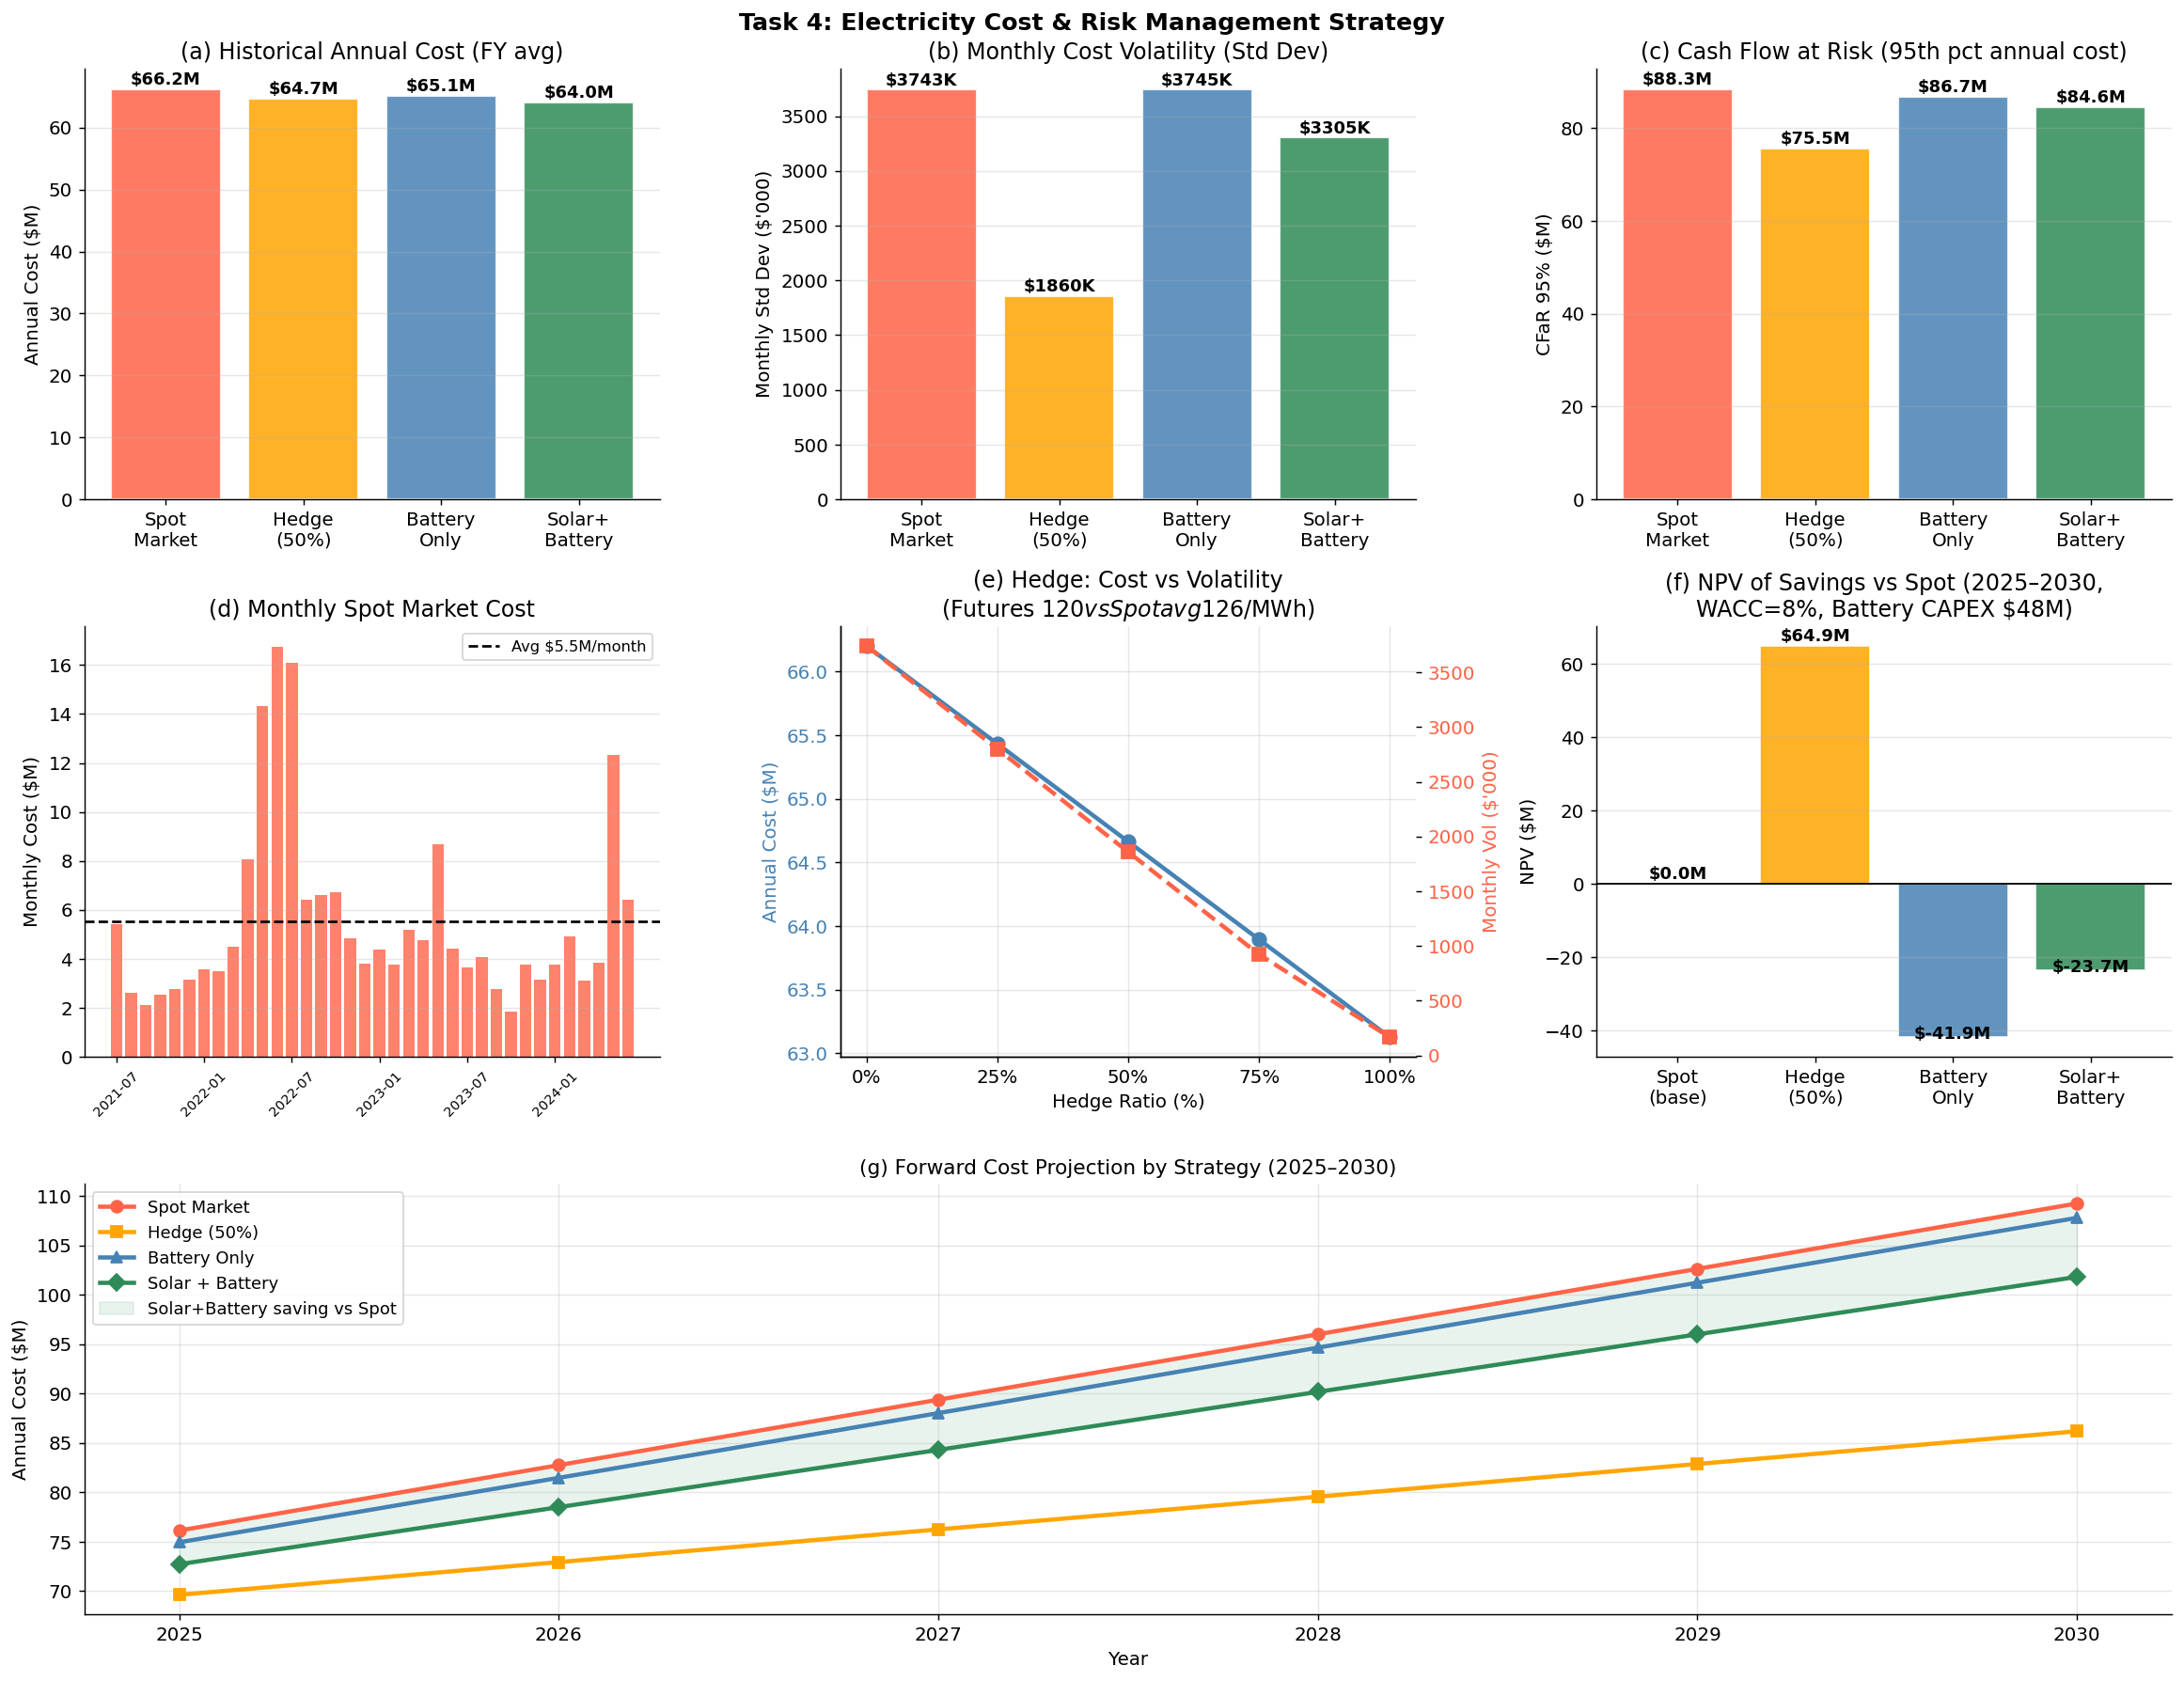

In [13]:
# ── Task 4 Visualisations ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Task 4: Electricity Cost & Risk Management Strategy',
             fontsize=14, fontweight='bold')

strategies_labels = ['Spot\nMarket', 'Hedge\n(50%)', 'Battery\nOnly', 'Solar+\nBattery']
bar_cols = ['tomato', 'orange', 'steelblue', 'seagreen']

hist_costs = [annual_spot_mean, annual_hedge_mean, annual_battery_cost, annual_sb_hist]
hist_stds  = [monthly_spot.std(), monthly_hedge.std(),
              monthly_battery.std(), monthly_sb.std()]
cfar95s    = [cfar_results[k]['cfar95'] for k in ['Spot','Hedge (50%)','Battery','Solar+Battery']]
npv_vals   = [0, npv_hedge, npv_bat, npv_sb]

# ── (a) Historical annual cost ────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
bars = ax1.bar(strategies_labels, [c/1e6 for c in hist_costs],
               color=bar_cols, alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, hist_costs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'${val/1e6:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('(a) Historical Annual Cost (FY avg)')
ax1.set_ylabel('Annual Cost ($M)'); ax1.grid(True, alpha=0.3, axis='y')

# ── (b) Monthly volatility ────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
bars2 = ax2.bar(strategies_labels, [s/1e3 for s in hist_stds],
                color=bar_cols, alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars2, hist_stds):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('(b) Monthly Cost Volatility (Std Dev)')
ax2.set_ylabel("Monthly Std Dev ($'000)"); ax2.grid(True, alpha=0.3, axis='y')

# ── (c) CFaR 95% ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
bars3 = ax3.bar(strategies_labels, [c/1e6 for c in cfar95s],
                color=bar_cols, alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars3, cfar95s):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'${val/1e6:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('(c) Cash Flow at Risk (95th pct annual cost)')
ax3.set_ylabel('CFaR 95% ($M)'); ax3.grid(True, alpha=0.3, axis='y')

# ── (d) Monthly spot cost bar ─────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
ax4.bar(monthly_spot.index.astype(str), monthly_spot.values/1e6,
        color='tomato', alpha=0.8)
ax4.axhline(y=annual_spot_mean/12/1e6, color='black', linestyle='--',
            linewidth=1.5, label=f'Avg ${annual_spot_mean/12/1e6:.1f}M/month')
ax4.set_title('(d) Monthly Spot Market Cost')
ax4.set_ylabel('Monthly Cost ($M)')
ax4.set_xticks(range(0, len(monthly_spot), 6))
ax4.set_xticklabels([str(monthly_spot.index[i]) for i in range(0, len(monthly_spot), 6)],
                    rotation=45, fontsize=8)
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3, axis='y')

# ── (e) Hedge cost-risk trade-off ─────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
hedge_ratios = [0.0, 0.25, 0.50, 0.75, 1.0]
hedge_costs2 = []
hedge_stds2  = []
for ratio in hedge_ratios:
    c = dc_loads * duration * (ratio*FUTURES_PRICE + (1-ratio)*prices)
    hedge_costs2.append(c.sum()/3)
    hedge_stds2.append(c.reshape(-1).reshape(-1)[:].view())

# Recalculate monthly stds per ratio
hedge_stds2 = []
for ratio in hedge_ratios:
    c = pd.Series(dc_loads * duration * (ratio*FUTURES_PRICE + (1-ratio)*prices),
                  index=df.index)
    monthly_h = c.groupby(df['datetime'].dt.to_period('M')).sum()
    hedge_stds2.append(monthly_h.std())

ax5_twin = ax5.twinx()
pcts = [int(r*100) for r in hedge_ratios]
ax5.plot(pcts, [c/1e6 for c in hedge_costs2], color='steelblue',
         linewidth=2.5, marker='o', markersize=8, label='Annual Cost ($M)')
ax5_twin.plot(pcts, [s/1e3 for s in hedge_stds2], color='tomato',
              linewidth=2.5, marker='s', markersize=8, linestyle='--',
              label="Monthly Vol ($'000)")
ax5.set_title(f'(e) Hedge: Cost vs Volatility\n(Futures ${FUTURES_PRICE} vs Spot avg ${prices.mean():.0f}/MWh)')
ax5.set_xlabel('Hedge Ratio (%)'); ax5.set_ylabel('Annual Cost ($M)', color='steelblue')
ax5_twin.set_ylabel("Monthly Vol ($'000)", color='tomato')
ax5.set_xticks(pcts); ax5.set_xticklabels([f'{p}%' for p in pcts])
ax5.tick_params(axis='y', labelcolor='steelblue')
ax5_twin.tick_params(axis='y', labelcolor='tomato')
ax5.grid(True, alpha=0.3)

# ── (f) NPV bars ──────────────────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
npv_labels = ['Spot\n(base)', 'Hedge\n(50%)', 'Battery\nOnly', 'Solar+\nBattery']
npv_cols = ['grey', 'orange', 'steelblue', 'seagreen']
bars6 = ax6.bar(npv_labels, [v/1e6 for v in npv_vals],
                color=npv_cols, alpha=0.85, edgecolor='white')
ax6.axhline(0, color='black', linewidth=1)
for bar, val in zip(bars6, npv_vals):
    ypos = bar.get_height() + (0.3 if val >= 0 else -1.5)
    ax6.text(bar.get_x()+bar.get_width()/2, ypos,
             f'${val/1e6:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax6.set_title(f'(f) NPV of Savings vs Spot (2025–2030,\nWACC={DISCOUNT_RATE*100:.0f}%, Battery CAPEX ${BATTERY_CAPEX/1e6:.0f}M)')
ax6.set_ylabel('NPV ($M)'); ax6.grid(True, alpha=0.3, axis='y')

# ── (g) Forward cost projection ───────────────────────────────────────
ax7 = fig.add_subplot(3, 1, 3)
ax7.plot(proj_years, [v/1e6 for v in spot_fwd_yr],    color='tomato',    linewidth=2.5,
         marker='o', markersize=7, label='Spot Market')
ax7.plot(proj_years, [v/1e6 for v in hedge_fwd_yr],   color='orange',    linewidth=2.5,
         marker='s', markersize=7, label=f'Hedge ({int(HEDGE_RATIO*100)}%)')
ax7.plot(proj_years, [v/1e6 for v in battery_fwd_yr], color='steelblue', linewidth=2.5,
         marker='^', markersize=7, label='Battery Only')
ax7.plot(proj_years, [v/1e6 for v in sb_fwd_yr],      color='seagreen',  linewidth=2.5,
         marker='D', markersize=7, label='Solar + Battery')
ax7.fill_between(proj_years,
                 [v/1e6 for v in spot_fwd_yr],
                 [v/1e6 for v in sb_fwd_yr],
                 alpha=0.1, color='seagreen', label='Solar+Battery saving vs Spot')
ax7.set_title('(g) Forward Cost Projection by Strategy (2025–2030)', fontsize=12)
ax7.set_xlabel('Year'); ax7.set_ylabel('Annual Cost ($M)')
ax7.legend(fontsize=10); ax7.grid(True, alpha=0.3); ax7.set_xticks(proj_years)

plt.tight_layout()
plt.savefig('task4_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**1. Strategy Cost Comparison — “Historical Annual Cost (FY avg)**

Spot market exposure is the most expensive option (~$66.2M per year).

A 50% hedge reduces cost slightly to $64.7M.

Battery‑only provides small savings but still costs ~$65.1M.

Solar + battery is the cheapest at $64.0M, due to low‑cost solar energy.

Shows that hedging and solar reduce average cost more effectively than batteries alone.

**2. Monthly Cost Volatility — “Monthly Std Dev”**

Spot market has the highest volatility (~$3.74M per month).

A 50% hedge cuts volatility by half, down to ~$1.86M.

Battery‑only does not reduce volatility — almost identical to spot.

Solar + battery reduces volatility moderately to ~$3.3M.

Demonstrates that hedging is the strongest tool for stabilising monthly costs.

**3. Cash Flow at Risk — “CFaR 95%”**

Spot market has the highest risk, with worst‑case annual cost of $88.3M.

A 50% hedge reduces worst‑case cost to $75.5M — the lowest risk of all strategies.

Battery‑only still has high risk (~$86.7M).

Solar + battery reduces risk slightly to $84.6M.

Confirms that hedging provides the best protection against extreme price events.

**4. Monthly Spot Market Cost — “(d) Monthly Spot Market Cost”**

Monthly spot costs fluctuate heavily, with large spikes in mid‑2022 and early 2024.

Average monthly cost is around $5.5M.

Shows why relying only on spot exposure creates unpredictable cash flows

**5. Hedge Ratio Curve — “(e) Hedge: Cost vs Volatility”**

As hedge ratio increases from 0% → 100%:

Annual cost decreases from ~$66M to ~$63M.

Volatility drops sharply from ~$3.5M to almost zero.

Shows a clear trade‑off: more hedging = lower volatility + lower cost.

Demonstrates why a 50% hedge is a balanced, cost‑effective strategy.

6. **NPV Comparison — “(f) NPV of Savings vs Spot (2025–2030)”
Spot is the baseline (NPV = $0)**

A 50% hedge has the highest NPV at +$64.9M — best financial outcome.

Battery‑only has a negative NPV (–$41.9M) due to high CAPEX.

Solar + battery also negative (–$23.7M), but better than battery alone.

Shows that hedging creates value, while batteries do not pay back under current assumptions.

7. **Forward Projection — “(g) Forward Cost Projection by Strategy (2025–2030)”
All strategies become more expensive over time due to rising market prices**

Spot market remains the most expensive every year.

Hedge (50%) stays the cheapest and most stable.

Solar + battery sits between hedge and spot, offering moderate savings.

The shaded region shows solar + battery savings vs spot, which grow over time.

Confirms that hedging is best for cost control, while solar + battery helps reduce long‑term exposure.

In [14]:
# ══════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════

print("=" * 95)
print("STRATEGY COMPARISON SUMMARY — 50 MW NSW DATA CENTRE")
print("=" * 95)
print(f"{'Strategy':<16} {'FY Avg':>9} {'2030 Cost':>10} {'Mo Std':>9} "
      f"{'CFaR95':>9} {'NPV':>9} {'CAPEX':>8} {'Payback':>9}")
print("-" * 95)

summary_rows = [
    ('Spot Market',    annual_spot_mean,    spot_fwd_yr[-1],
     monthly_spot.std(),    cfar_results['Spot']['cfar95'],
     0,          0,              'N/A'),
    ('Hedge (50%)',    annual_hedge_mean,   hedge_fwd_yr[-1],
     monthly_hedge.std(),   cfar_results['Hedge (50%)']['cfar95'],
     npv_hedge,  0,              'immediate'),
    ('Battery Only',  annual_battery_cost, battery_fwd_yr[-1],
     monthly_battery.std(), cfar_results['Battery']['cfar95'],
     npv_bat,    BATTERY_CAPEX,  f'{payback_bat_fwd:.1f} yrs'),
    ('Solar+Battery', annual_sb_hist,      sb_fwd_yr[-1],
     monthly_sb.std(),      cfar_results['Solar+Battery']['cfar95'],
     npv_sb,     BATTERY_CAPEX,  f'{payback_sb_fwd:.1f} yrs'),
]

for name, hist, proj, std, cfar, npv, capex, pb in summary_rows:
    capex_s = f'${capex/1e6:.0f}M' if capex > 0 else '$0'
    npv_s   = f'${npv/1e6:.1f}M'
    print(f"{name:<16} ${hist/1e6:>6.1f}M   ${proj/1e6:>7.1f}M  ${std/1e3:>6.0f}K  "
          f"${cfar/1e6:>6.1f}M  {npv_s:>9}  {capex_s:>8}  {pb:>9}")

print("=" * 95)
print(f"\nKey findings:")
print(f"1. Spot market:   ${annual_spot_mean/1e6:.1f}M/yr avg with ${annual_spot_fy.max()/1e6:.1f}M worst FY — high CFaR")
print(f"2. Hedge (50%):   saves ${(annual_spot_mean-annual_hedge_mean)/1e6:.1f}M/yr, NPV ${npv_hedge/1e6:.1f}M, zero CAPEX")
print(f"3. Battery:       NPV ${npv_bat/1e6:.1f}M, payback {payback_bat_fwd:.1f} yrs on projected prices")
print(f"4. Solar+Battery: NPV ${npv_sb/1e6:.1f}M, payback {payback_sb_fwd:.1f} yrs — best long-term hedge")
print(f"\nRecommendation: Implement 50% futures hedge immediately (zero CAPEX, positive NPV).")
print(f"Commission solar+battery PPA+BESS for FY2026 commissioning to lock in long-run savings.")


STRATEGY COMPARISON SUMMARY — 50 MW NSW DATA CENTRE
Strategy            FY Avg  2030 Cost    Mo Std    CFaR95       NPV    CAPEX   Payback
-----------------------------------------------------------------------------------------------
Spot Market      $  66.2M   $  109.2M  $  3743K  $  88.3M      $0.0M        $0        N/A
Hedge (50%)      $  64.7M   $   86.2M  $  1860K  $  75.5M     $64.9M        $0  immediate
Battery Only     $  65.1M   $  107.8M  $  3745K  $  86.7M    $-41.9M      $48M   35.8 yrs
Solar+Battery    $  64.0M   $  101.8M  $  3305K  $  84.6M    $-23.7M      $48M    8.8 yrs

Key findings:
1. Spot market:   $66.2M/yr avg with $75.7M worst FY — high CFaR
2. Hedge (50%):   saves $1.5M/yr, NPV $64.9M, zero CAPEX
3. Battery:       NPV $-41.9M, payback 35.8 yrs on projected prices
4. Solar+Battery: NPV $-23.7M, payback 8.8 yrs — best long-term hedge

Recommendation: Implement 50% futures hedge immediately (zero CAPEX, positive NPV).
Commission solar+battery PPA+BESS for FY2026 

The final comparison shows clear differences in both cost and risk across the four electricity‑procurement strategies. Full spot‑market exposure is the most expensive and volatile option, with the highest Cash Flow at Risk and no protection against price spikes. A 50% hedge consistently delivers the strongest performance, offering the lowest volatility, the lowest worst‑case annual cost, and the highest NPV of savings with no upfront capital required. Battery‑only provides minimal cost benefit and does not reduce volatility, while its high capital cost results in a negative NPV and long payback. The solar‑plus‑battery option lowers annual costs slightly more than hedging and reduces risk moderately, but still produces a negative NPV due to battery CAPEX. Overall, the results show that hedging provides the best balance of cost, stability, and financial value, while solar‑plus‑battery becomes attractive only in the long term as technology costs fall.